# Uploading Data

In [4]:
%pip install cmasher

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [cmasher]
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install imageio-ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 52.3 MB/s  0:00:00m0:00:010:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import sys
import numpy as np
from matplotlib.ticker import ScalarFormatter
sys.path.insert(0, '/Users/deal.137/Magnetar/athena/vis/python')
import athena_read
import matplotlib as mpl
import matplotlib.pyplot as plt
import cmasher as cmr
from scipy.interpolate import interp2d

data = athena_read.athdf('/Users/jackson.4406/Magnetar_OSC_OG/test050326_shell_10frames/parker.prim.00007.athdf')
r=data['x1v']
vr=data['vel1']
rho=data['rho']
press=data['press']


data_uov = athena_read.athdf('/Users/jackson.4406/Magnetar_OSC_OG/test050326_shell_10frames/parker.uov.00007.athdf')
temp=data_uov['dt1'] #temperature
qdot=data_uov['dt2'] #neutrino heating/cooling rate
cs=data_uov['dt3']   #adiabatic sound speed




## Graphing Snapshots

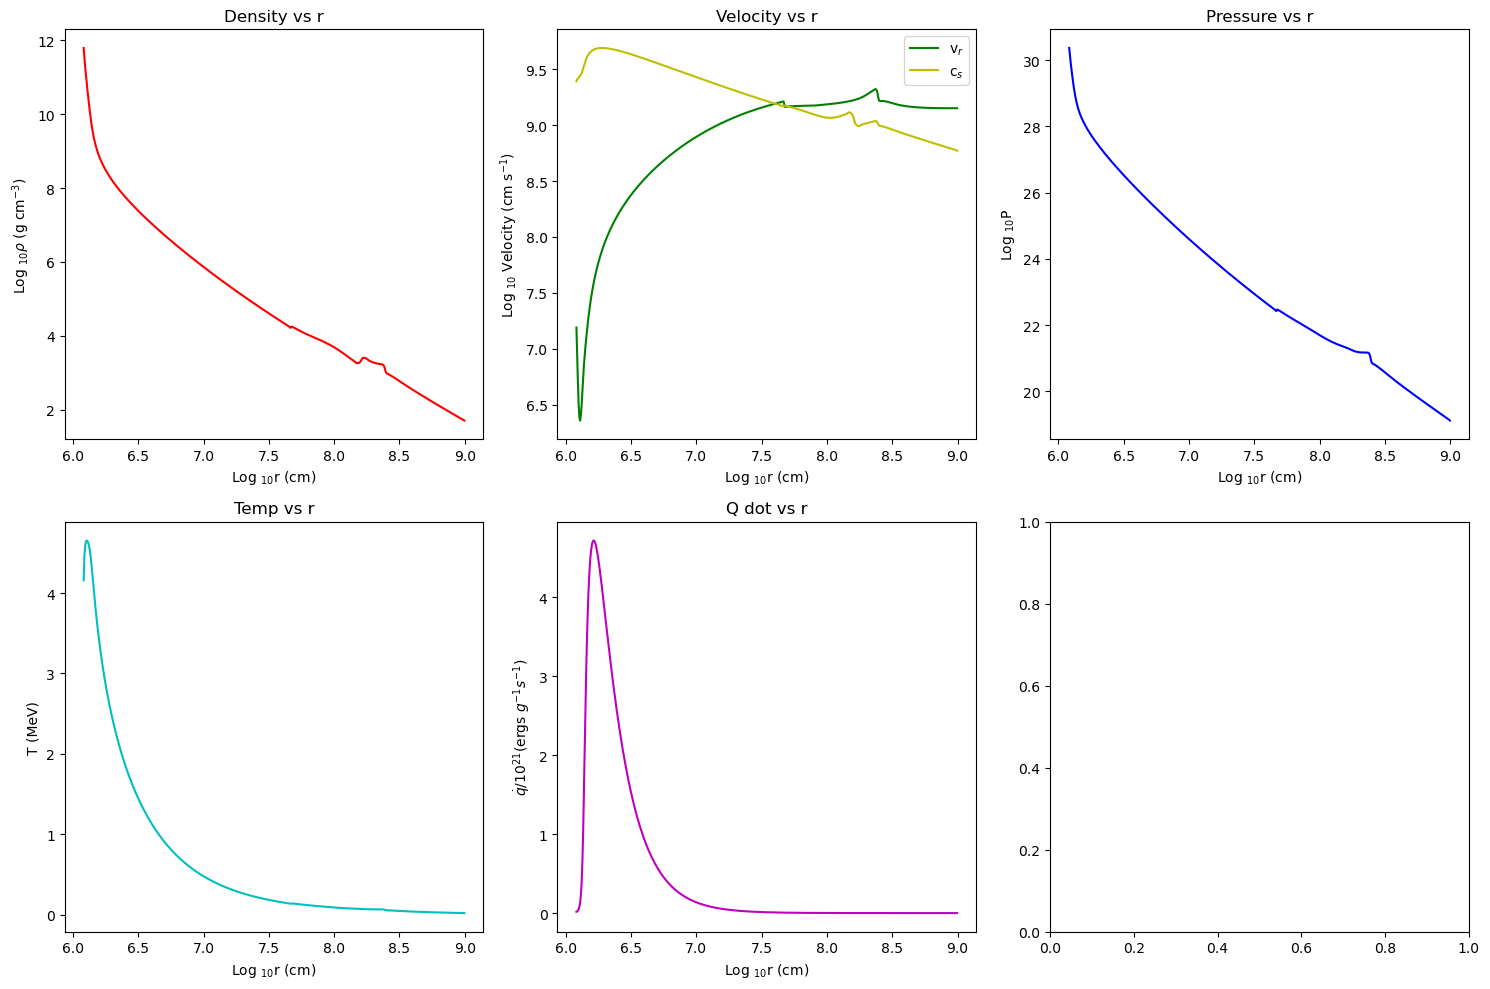

In [3]:
import matplotlib.pyplot as plt
# Create subplots
fig, axs = plt.subplots(2, 3, figsize=(15, 10))  # 1 row, 3 columns

# First scatter plot
axs[0,0].plot(np.log10(r),np.log10(rho[0][0]), color='r')
axs[0,0].set_title('Density vs r')
axs[0,0].set_xlabel('Log $_{10}$r (cm)')
axs[0,0].set_ylabel(r'Log $_{10}\rho$ (g cm$^{-3}$)')

# Second scatter plot
axs[0,1].plot(np.log10(r),np.log10(vr[0][0]), color='g',label='v$_r$')
axs[0,1].plot(np.log10(r),np.log10(cs[0][0]), color='y', label = 'c$_s$')
axs[0,1].set_title('Velocity vs r')
axs[0,1].set_xlabel('Log $_{10}$r (cm)')
axs[0,1].set_ylabel(r'Log $_{10}$ Velocity (cm s$^{-1}$)')
axs[0,1].legend()
# Third scatter plot
axs[0,2].plot(np.log10(r),np.log10(press[0][0]), color='b')
axs[0,2].set_title('Pressure vs r')
axs[0,2].set_xlabel('Log $_{10}$r (cm)')
axs[0,2].set_ylabel('Log $_{10}$P')


# Fourth scatter plot
axs[1, 0].plot(np.log10(r),temp[0][0]/10**10, color='c')
axs[1, 0].set_title('Temp vs r')
axs[1, 0].set_xlabel('Log $_{10}$r (cm)')
axs[1, 0].set_ylabel('T (MeV)')

# Fifth scatter plot
axs[1, 1].plot(np.log10(r),qdot[0][0]/10**21, color='m')
axs[1, 1].set_title('Q dot vs r')
axs[1, 1].set_xlabel('Log $_{10}$r (cm)')
axs[1, 1].set_ylabel('$\dot{q} / 10^{21}$(ergs $g^{−1} s^{−1})$')







# Adjust layout
plt.tight_layout()

# Display the plot

plt.savefig("Magnetar_shell_nofield.png")
plt.show()


# Check file for dimensions

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation  # <--- This was missing!
import imageio_ffmpeg
import sys

import h5py
import numpy as np
import matplotlib.pyplot as plt
import sys
import numpy as np
from matplotlib.ticker import ScalarFormatter
sys.path.insert(0, '/Users/deal.137/Magnetar/athena/vis/python')
import athena_read
import matplotlib as mpl
import matplotlib.pyplot as plt
import cmasher as cmr
from scipy.interpolate import interp2d
import imageio_ffmpeg
import os

# --- 1. Path & Engine Setup ---
plt.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()
athena_path = '/Users/deal.137/Magnetar/athena/vis/python'
if athena_path not in sys.path:
    sys.path.insert(0, athena_path)


import sys
import os

# 1. Tell Python where your local athena tools are located
# (Adjust this path if your 'athena/vis/python' folder is somewhere else locally)
athena_utils_path = r'C:\Users\jackson.4406\Magnetar_OSC_OG\athena\vis\python'
if athena_utils_path not in sys.path:
    sys.path.insert(0, athena_utils_path)

import athena_read

# 2. Define your exact local file path using a raw string
local_file_path = r'/Users/jackson.4406/Magnetar_OSC_OG/test052726_1D_hydro/parker.prim.00001.athdf'

# 3. Read and check the shape
try:
    data = athena_read.athdf(local_file_path)
    print("Successfully read local file!")
    print("----------------------------------------")
    print("Density array shape:", data['rho'].shape)
    print("Radial grid zones (nx1):", data['x1v'].shape[0])
    print("----------------------------------------")
    
    # Quick sanity check printout based on the shape
    if data['rho'].shape[0] == 1 and data['rho'].shape[1] == 1:
        print("✅ VERIFIED: This is a true 1D simulation! (Phi and Theta are collapsed to 1)")
    else:
        print("❌ WARNING: This looks like a 2D or 3D simulation array.")

except FileNotFoundError:
    print(f"Could not find the file at: {local_file_path}")
    print("Double check if the folder name or file extension matches what was downloaded.")

Successfully read local file!
----------------------------------------
Density array shape: (1, 1, 256)
Radial grid zones (nx1): 256
----------------------------------------
✅ VERIFIED: This is a true 1D simulation! (Phi and Theta are collapsed to 1)


# Graph Animations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation  # <--- This was missing!
import imageio_ffmpeg
import sys

import h5py
import numpy as np
import matplotlib.pyplot as plt
import sys
import numpy as np
from matplotlib.ticker import ScalarFormatter
sys.path.insert(0, '/Users/deal.137/Magnetar/athena/vis/python')
import athena_read
import matplotlib as mpl
import matplotlib.pyplot as plt
import cmasher as cmr
from scipy.interpolate import interp2d
import imageio_ffmpeg
import os


# --- 1. Path & Engine Setup ---
plt.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()
athena_path = '/Users/deal.137/Magnetar/athena/vis/python'
if athena_path not in sys.path:
    sys.path.insert(0, athena_path)

# --- 2. Configuration ---
# Create the list of densities from 1.1 to 2.0
densities = [f"{x:.1f}" for x in np.linspace(10, 10,1)]
#densities = [f"{x:.1f}" for x in np.arange(1.5, 5.1, 0.5)]
file_prefix = 'parker'
num_frames = 40
msolar = 2e33

# --- 3. Automation Loop ---
for density in densities:
    # Update base_path for the current density folder
    base_path = f'/Users/jackson.4406/Magnetar_OSC_OG/test052626_hydro_density_{density}_t0.5/'
    output_video = f'052626_magentar_density_{density}.mp4'
    
    print(f"Starting rendering for Density {density}...")
    
    # Initialize the 6-panel figure
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    def update(frame):
        for ax in axs.flat:
            ax.clear()
        filenum = str(frame).zfill(5)
        try:
            # Load Data from the specific density path
            data = athena_read.athdf(f'{base_path}{file_prefix}.prim.{filenum}.athdf')
            data_uov = athena_read.athdf(f'{base_path}{file_prefix}.uov.{filenum}.athdf')
            
            sim_time_ms = (data['Time']) * 1000
            
            r = data['x1v']
            log_r = np.log10(r)

            # --- Plotting Logic (Same as your original Code 15) ---
            # Panel 1: Density
            axs[0, 0].plot(log_r, np.log10(data['rho'][0][0]), color='r')
            axs[0, 0].set_title(f'Density Profile (Shell {density})')
            axs[0, 0].set_ylabel(r'Log$_{10}\rho$ (g/cm$^3$)')

            # Panel 2: Velocity & Sound Speed
            axs[0, 1].plot(log_r, np.log10(np.abs(data['vel1'][0][0])), color='g', label='|v$_r$|')
            axs[0, 1].plot(log_r, np.log10(data_uov['dt3'][0][0]), color='y', label='c$_s$')
            axs[0, 1].set_title('Velocity & Sound Speed')
            axs[0, 1].legend(loc='upper right')

            # Panel 3: Pressure
            axs[0, 2].plot(log_r, np.log10(data['press'][0][0]), color='b')
            axs[0, 2].set_title('Pressure Profile')

            # Panel 4: Temperature
            axs[1, 0].plot(log_r, data_uov['dt1'][0][0] / 1e10, color='c')
            axs[1, 0].set_title('Temperature')
            axs[1, 0].set_ylabel('T (MeV)')

            # Panel 5: Q Dot
            axs[1, 1].plot(log_r, data_uov['dt2'][0][0] / 1e21, color='m')
            axs[1, 1].set_title('Neutrino Heating (Q dot)')
            axs[1, 1].set_ylabel(r'$\dot{q} / 10^{21}$')

            # Panel 6: Mdot
            rho, vr = data['rho'], data['vel1']
            sth = np.sin(data['x2v'])[np.newaxis, :, np.newaxis]
            dphi = np.diff(data['x3f'])[:, np.newaxis, np.newaxis]
            dth = np.diff(data['x2f'])[np.newaxis, :, np.newaxis]
            r_3d = r[np.newaxis, np.newaxis, :]
            mdot = np.sum(rho * vr * sth * r_3d**2 * dth * dphi, axis=(0, 1))
            axs[1, 2].plot(log_r, mdot / msolar, color='orange')
            axs[1, 2].set_title('Mdot Profile')

            fig.suptitle(f'Density Factor: {density} | Initial Temp Scaled 0.5x | Time: {sim_time_ms:.2f} ms', fontsize=22, fontweight='bold')

        except Exception as e:
            # Optionally print error if a specific frame is missing
            pass

    # Save current density animation
    ani = FuncAnimation(fig, update, frames=range(num_frames), interval=100)
    ani.save(output_video, writer='ffmpeg', fps=10)
    plt.close(fig)
    print(f"Successfully created: {output_video}")

print("\n--- All videos have been rendered! ---")

Starting rendering for Density 10.0...
Successfully created: 052626_magentar_density_10.0.mp4

--- All videos have been rendered! ---


In [3]:
# --- 2. Configuration ---
# Target the single specific density folder directly
density = "10" 
file_prefix = 'parker'
num_frames = 40
msolar = 2e33

# --- 3. Automation (Single Folder) ---
# Update base_path for the specific density folder
base_path = f'/Users/jackson.4406/Magnetar_OSC_OG/test052626_hydro_density_{density}/'
output_video = f'052626_magentar_density_{density}.mp4'

print(f"Starting rendering for Density {density}...")

# Initialize the 6-panel figure
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

def update(frame):
    for ax in axs.flat:
        ax.clear()
    filenum = str(frame).zfill(5)
    try:
        # Load Data from the specific density path
        data = athena_read.athdf(f'{base_path}{file_prefix}.prim.{filenum}.athdf')
        data_uov = athena_read.athdf(f'{base_path}{file_prefix}.uov.{filenum}.athdf')
        
        sim_time_ms = (data['Time']) * 1000
        r = data['x1v']
        log_r = np.log10(r)
        
        # --- Plotting Logic ---
        # Panel 1: Density
        axs[0, 0].plot(log_r, np.log10(data['rho'][0][0]), color='r')
        axs[0, 0].set_title(f'Density Profile (Shell {density})')
        axs[0, 0].set_ylabel(r'Log$_{10}\rho$ (g/cm$^3$)')
        
        # Panel 2: Velocity & Sound Speed
        axs[0, 1].plot(log_r, np.log10(np.abs(data['vel1'][0][0])), color='g', label='|v$_r$|')
        axs[0, 1].plot(log_r, np.log10(data_uov['dt3'][0][0]), color='y', label='c$_s$')
        axs[0, 1].set_title('Velocity & Sound Speed')
        axs[0, 1].legend(loc='upper right')
        
        # Panel 3: Pressure
        axs[0, 2].plot(log_r, np.log10(data['press'][0][0]), color='b')
        axs[0, 2].set_title('Pressure Profile')
        
        # Panel 4: Temperature
        axs[1, 0].plot(log_r, data_uov['dt1'][0][0] / 1e10, color='c')
        axs[1, 0].set_title('Temperature')
        axs[1, 0].set_ylabel('T (MeV)')
        
        # Panel 5: Q Dot
        axs[1, 1].plot(log_r, data_uov['dt2'][0][0] / 1e21, color='m')
        axs[1, 1].set_title('Neutrino Heating (Q dot)')
        axs[1, 1].set_ylabel(r'$\dot{q} / 10^{21}$')
        
        # Panel 6: Mdot
        rho, vr = data['rho'], data['vel1']
        sth = np.sin(data['x2v'])[np.newaxis, :, np.newaxis]
        dphi = np.diff(data['x3f'])[:, np.newaxis, np.newaxis]
        dth = np.diff(data['x2f'])[np.newaxis, :, np.newaxis]
        r_3d = r[np.newaxis, np.newaxis, :]
        mdot = np.sum(rho * vr * sth * r_3d ** 2 * dth * dphi, axis=(0, 1))
        
        axs[1, 2].plot(log_r, mdot / msolar, color='orange')
        axs[1, 2].set_title('Mdot Profile')
        
        fig.suptitle(f'Density Factor: {density} | Time: {sim_time_ms:.2f} ms', fontsize=22, fontweight='bold')
        
    except Exception as e:
        # Optionally print(e) if things break down to debug filenames
        pass

# Save current density animation
ani = FuncAnimation(fig, update, frames=range(num_frames), interval=100)
ani.save(output_video, writer='ffmpeg', fps=10)
plt.close(fig)

print(f"Successfully created: {output_video}")

Starting rendering for Density 10...
Successfully created: 052626_magentar_density_10.mp4


In [8]:
# --- 2. Configuration ---
# Hardcoded local path to your 1D hydro simulation folder
base_path = r'/Users/jackson.4406/Magnetar_OSC_OG/test052726_1D_hydro/'
file_prefix = 'parker'
num_frames = 11    # Updated to process your 100 dumped files
msolar = 2e33

output_video = '052726_1D_hydro_simulation.mp4'

print(f"Starting rendering for 1D Hydro simulation from: {base_path}")

# Initialize the 6-panel figure
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

def update(frame):
    for ax in axs.flat:
        ax.clear()
    
    # Files start at 00001 and go to 00100 based on your dcycle settings
    filenum = str(frame + 1).zfill(5) 
    
    try:
        # Configured for your exact file streams (.prim and .uov)
        data = athena_read.athdf(f'{base_path}{file_prefix}.prim.{filenum}.athdf')
        data_uov = athena_read.athdf(f'{base_path}{file_prefix}.uov.{filenum}.athdf')
        
        sim_time_ms = (data['Time']) * 1000
        r = data['x1v']
        log_r = np.log10(r)
        
        # --- Plotting Logic ---
        # Panel 1: Density
        axs[0, 0].plot(log_r, np.log10(data['rho'][0][0]), color='r')
        axs[0, 0].set_title('Density Profile (1D Hydro)')
        axs[0, 0].set_ylabel(r'Log$_{10}\rho$ (g/cm$^3$)')
        
        # Panel 2: Velocity & Sound Speed
        axs[0, 1].plot(log_r, np.log10(np.abs(data['vel1'][0][0])), color='g', label='|v$_r$|')
        axs[0, 1].plot(log_r, np.log10(data_uov['dt3'][0][0]), color='y', label='c$_s$')
        axs[0, 1].set_title('Velocity & Sound Speed')
        axs[0, 1].legend(loc='upper right')
        
        # Panel 3: Pressure
        axs[0, 2].plot(log_r, np.log10(data['press'][0][0]), color='b')
        axs[0, 2].set_title('Pressure Profile')
        
        # Panel 4: Temperature
        axs[1, 0].plot(log_r, data_uov['dt1'][0][0] / 1e10, color='c')
        axs[1, 0].set_title('Temperature')
        axs[1, 0].set_ylabel('T (MeV)')
        
        # Panel 5: Q Dot
        axs[1, 1].plot(log_r, data_uov['dt2'][0][0] / 1e21, color='m')
        axs[1, 1].set_title('Neutrino Heating (Q dot)')
        axs[1, 1].set_ylabel(r'$\dot{q} / 10^{21}$')
        
        # Panel 6: Mdot
        rho, vr = data['rho'], data['vel1']
        sth = np.sin(data['x2v'])[np.newaxis, :, np.newaxis]
        dphi = np.diff(data['x3f'])[:, np.newaxis, np.newaxis]
        dth = np.diff(data['x2f'])[np.newaxis, :, np.newaxis]
        r_3d = r[np.newaxis, np.newaxis, :]
        mdot = np.sum(rho * vr * sth * r_3d ** 2 * dth * dphi, axis=(0, 1))
        
        axs[1, 2].plot(log_r, mdot / msolar, color='orange')
        axs[1, 2].set_title('Mdot Profile')
        
        fig.suptitle(f'1D Rotation Simulation | Time: {sim_time_ms:.2f} ms', fontsize=22, fontweight='bold')
        
    except Exception as e:
        # If any file fails to load, it will print out the specific file path causing issues
        print(f"Error loading frame {filenum}: {e}")

# Save current animation loop
ani = FuncAnimation(fig, update, frames=range(num_frames), interval=100)
ani.save(output_video, writer='ffmpeg', fps=10)
plt.close(fig)

print(f"Successfully created: {output_video}")

Starting rendering for 1D Hydro simulation from: /Users/jackson.4406/Magnetar_OSC_OG/test052726_1D_hydro/
Successfully created: 052726_1D_hydro_simulation.mp4


# Time checks

In [5]:
import glob
import numpy as np
import athena_read

# --- 2. Configuration ---
# Cleaned up the spacing inside the f-string so the folder names evaluate perfectly
densities = [f"{x:.1f}" for x in np.linspace(1.1, 1.1, 1)]
file_prefix = 'parker' 
num_frames = 101
msolar = 2e33

# --- 3. Automation Loop ---
print("=== Athena++ Simulation Time Tracker ===")

for density in densities:
    # This now evaluates cleanly to: .../test052226_hydro_shell_1.1/
    base_path = f'/Users/jackson.4406/Magnetar_OSC_OG/test052226_hydro_shell_{density}/'
    
    search_path = f"{base_path}{file_prefix}.prim.*.athdf"
    files = sorted(glob.glob(search_path))
    
    if not files:
        continue
        
    print(f"\n📁 Folder: test052226_hydro_shell_{density}/ ({len(files)} frames found)")
    print("-" * 65)
    
    for f in files:
        try:
            # Load only file headers for maximum processing speed
            data = athena_read.athdf(f) 
            raw_code_time = data['Time']
            
            # Convert internal code time to physical milliseconds
            physical_time_ms = (raw_code_time * 9.64267e-5) * 1000
            
            # Safely extract the frame number from the end of the file string
            frame_num = f.split('.')[-2]
            
            print(f"  Frame {frame_num} -> Raw Code Time: {raw_code_time:<12.6e} | Physical Time: {physical_time_ms:.4f} ms")
        except Exception as e:
            print(f"  Frame {f.split('/')[-1]} could not be parsed. Error: {e}")

=== Athena++ Simulation Time Tracker ===

📁 Folder: test052226_hydro_shell_1.1/ (102 frames found)
-----------------------------------------------------------------
  Frame 00000 -> Raw Code Time: 0.000000e+00 | Physical Time: 0.0000 ms
  Frame 00001 -> Raw Code Time: 2.379839e-02 | Physical Time: 0.0023 ms
  Frame 00002 -> Raw Code Time: 4.811482e-02 | Physical Time: 0.0046 ms
  Frame 00003 -> Raw Code Time: 7.243198e-02 | Physical Time: 0.0070 ms
  Frame 00004 -> Raw Code Time: 9.675096e-02 | Physical Time: 0.0093 ms
  Frame 00005 -> Raw Code Time: 1.210705e-01 | Physical Time: 0.0117 ms
  Frame 00006 -> Raw Code Time: 1.453903e-01 | Physical Time: 0.0140 ms
  Frame 00007 -> Raw Code Time: 1.697102e-01 | Physical Time: 0.0164 ms
  Frame 00008 -> Raw Code Time: 1.940302e-01 | Physical Time: 0.0187 ms
  Frame 00009 -> Raw Code Time: 2.183501e-01 | Physical Time: 0.0211 ms
  Frame 00010 -> Raw Code Time: 2.426701e-01 | Physical Time: 0.0234 ms
  Frame 00011 -> Raw Code Time: 2.669900e-0

In [10]:
import glob
import numpy as np
import athena_read

densities = [f"{x:.1f}" for x in np.linspace(1.1, 1.1, 1)]

print("=== Complete Inner Grid & Boundary State Tracker ===")

for density in densities:
    base_path = f'/Users/jackson.4406/Magnetar_OSC_OG/test052226_hydro_shell_{density}/'
    
    # Locate both the primitive and user-output file streams
    prim_files = sorted(glob.glob(f"{base_path}parker.prim.*.athdf"))
    uov_files = sorted(glob.glob(f"{base_path}parker.uov.*.athdf"))
    
    if not prim_files or not uov_files:
        print(f"\n📁 Folder: test052226_hydro_shell_{density}/ is missing files.")
        continue
        
    print(f"\n📁 Folder: test052226_hydro_shell_{density}/")
    print("-" * 85)
    
    # Inspect the very first snapshot (Frame 00000) for both files
    data_prim = athena_read.athdf(prim_files[0])
    data_uov = athena_read.athdf(uov_files[0])
    
    # 1. Mesh Geometry & Spacing
    inner_r_face0 = data_prim['x1f'][0]
    inner_r_face1 = data_prim['x1f'][1]
    inner_r = data_prim['x1v'][0]
    inner_dx = inner_r_face1 - inner_r_face0
    
    # 2. Fluid Primitives (from .prim file)
    inner_rho = data_prim['rho'][0, 0, 0]
    inner_vel = data_prim['vel1'][0, 0, 0]
    inner_press = data_prim['press'][0, 0, 0]
    
    # 3. Thermodynamics & Acoustics (from .uov file)
    # 'dt3' contains the sound speed calculated by your Helmholtz EOS solver
    inner_cs = data_uov['dt3'][0, 0, 0]
    mach_number = inner_vel / inner_cs
    
    # 4. Print Unified Output
    print(f"  [MESH]  Inner Cell Radius: {inner_r:.4e} cm | Width (dx): {inner_dx:.4e} cm")
    print(f"  [FLUID] Density (rho):     {inner_rho:.4e} g/cm³| Pressure:   {inner_press:.4e} dyn/cm²")
    print(f"  [WIND]  Velocity (v):      {inner_vel:.4e} cm/s | Sound Speed: {inner_cs:.4e} cm/s")
    print(f"  [DIAG]  Mach Number (M):   {mach_number:.4f}")

=== Complete Inner Grid & Boundary State Tracker ===

📁 Folder: test052226_hydro_shell_1.1/
-------------------------------------------------------------------------------------
  [MESH]  Inner Cell Radius: 1.2162e+06 cm | Width (dx): 3.2047e+04 cm
  [FLUID] Density (rho):     9.1512e+11 g/cm³| Pressure:   3.8669e+30 dyn/cm²
  [WIND]  Velocity (v):      5.1009e+04 cm/s | Sound Speed: 2.6274e+09 cm/s
  [DIAG]  Mach Number (M):   0.0000


# Make a video with all the densities velocities together

In [4]:

import h5py
import numpy as np
import matplotlib.pyplot as plt
import sys
import numpy as np
from matplotlib.ticker import ScalarFormatter
sys.path.insert(0, '/Users/deal.137/Magnetar/athena/vis/python')
import athena_read
import matplotlib as mpl
import matplotlib.pyplot as plt
import cmasher as cmr
from scipy.interpolate import interp2d
import imageio_ffmpeg
import os


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import athena_read
import imageio_ffmpeg
import sys

# --- 1. Path & Engine Setup ---
plt.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()
athena_path = '/Users/deal.137/Magnetar/athena/vis/python'
if athena_path not in sys.path:
    sys.path.insert(0, athena_path)

# --- 2. Configuration ---
#densities = [f"{x:.1f}" for x in np.linspace(1.1, 1.4, 4)]
densities = [f"{x:.1f}" for x in np.arange(1.5, 5.1, 0.5)]
base_folder = '/Users/jackson.4406/Magnetar_OSC_OG/'
file_prefix = 'parker'
num_frames = 101

# --- 3. Setup Figure (Log Scale Matching) ---
# sharex and sharey ensure the scale is identical across all 10 plots
fig, axs = plt.subplots(2, 5, figsize=(25, 10), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.3, wspace=0.1)

def update(frame):
    filenum = str(frame).zfill(5)
    
    for idx, density in enumerate(densities):
        ax = axs.flat[idx]
        ax.clear()
        
        folder_path = f"{base_folder}test052526_hydro_shell_{density}/"
        prim_path = f"{folder_path}{file_prefix}.prim.{filenum}.athdf"
        uov_path = f"{folder_path}{file_prefix}.uov.{filenum}.athdf"
        
        try:
            data = athena_read.athdf(prim_path)
            data_uov = athena_read.athdf(uov_path)
            
            r = data['x1v']
            log_r = np.log10(r)
            
            # Applying Log10 to match your reference code
            log_vr = np.log10(np.abs(data['vel1'][0][0]))
            log_cs = np.log10(data_uov['dt3'][0][0])
            
            # Plotting with the same colors and labels
            ax.plot(log_r, log_vr, color='g', label='|v$_r$|')
            ax.plot(log_r, log_cs, color='y', label='c$_s$')
            
            ax.set_title(f'Density Factor: {density}', fontsize=14)
            
            # Formatting
            if idx >= 5: ax.set_xlabel('Log$_{10}$r (cm)')
            if idx % 5 == 0: ax.set_ylabel('Log$_{10}$ Velocity / $c_s$')
            if idx == 4: ax.legend(loc='upper right')
            
            ax.grid(True, alpha=0.2)
            
            if idx == 0:
                sim_time = data['Time'] * 1000
                fig.suptitle(f'Log Scale Velocity & Sound Speed Comparison | Time: {sim_time:.2f} ms', 
                             fontsize=22, fontweight='bold')
                             
        except Exception:
            ax.text(0.5, 0.5, 'Data Missing', transform=ax.transAxes, ha='center', color='red')

# --- 4. Render Video ---
print("Rendering 10-panel log-scale comparison...")
ani = FuncAnimation(fig, update, frames=range(num_frames), interval=100)
output_name = '052526_log_velocity_cs_comparison_1.5_to_5.0.mp4'
ani.save(output_name, writer='ffmpeg', fps=10)
plt.close(fig)

print(f"Success! Video saved as: {output_name}")

Rendering 10-panel log-scale comparison...
Success! Video saved as: 052526_log_velocity_cs_comparison_1.5_to_5.0.mp4


In [4]:
import athena_read
# Check the last frame (100)
data_final = athena_read.athdf('/Users/jackson.4406/Magnetar_OSC_OG/parker.prim.00101.athdf')
print(f"Final Physical Time: {data_final['Time']* 1000:.4f} ms")

Final Physical Time: 0.0023 ms


# Color map with Mag Field

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import athena_read
import cmasher as cmr
from scipy.interpolate import RectBivariateSpline
import os

# === Load Athena++ data ===
prim_file = '/Users/jackson.4406/crashplan-restore-01132026-191525/Users/deal.137/Magnetar/test040426_sr_mag_rot_20frames/parker.prim.00002.athdf'
uov_file = '/Users/jackson.4406/crashplan-restore-01132026-191525/Users/deal.137/Magnetar/test040426_sr_mag_rot_20frames/parker.uov.00002.athdf'


#prim_file = '/Users/deal.137/magnetar_Osc/out_mag/parker.prim.00005.athdf'
#uov_file = '/Users/deal.137/magnetar_Osc/out_mag/parker.uov.00005.athdf'
data = athena_read.athdf(prim_file)
data_uov = athena_read.athdf(uov_file)
#=== Extract coordinates and variable with masking ===
r_min = np.min(data['x1v']) #set r_min
r_max= 1e7
mask= (data['x1v'] >= r_min) & (data['x1v'] <= r_max)
# Create a separate mask for the cell face data
mask_f = (data['x1f'] >= r_min) & (data['x1f'] <= r_max)


# === Extract coordinates and variables ===
r = data['x1v'][mask]
theta = data['x2v']
rf = data['x1f'][mask_f]
thetaf = data['x2f']
vr = data['vel1'][0][:,mask]
vphi = data['vel3'][0][:, mask]
temp = data_uov['dt1'][0][:,mask]
br = data['Bcc1'][0][:,mask]
bth = data['Bcc2'][0][:,mask]

# === Create polar plot ===
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))

# === Create meshgrids ===
r_grid, theta_grid = np.meshgrid(r, theta)

# === Plot radial velocity ===
norm_vr = mpl.colors.Normalize(vmin=0, vmax=np.max(vr)/1e9)
pcm_vr = ax.pcolormesh(theta_grid, r_grid, vr / 1e9, cmap='magma', shading='auto', norm=norm_vr)
cb1 = plt.colorbar(pcm_vr, ax=ax, location='left', fraction=0.05)
cb1.set_label(r'$v_r\ \left[10^9\ {\rm cm}\ {\rm s}^{-1}\right]$')

# === Plot azimuthal velocity ===
vmax_phi= np.max(np.abs(vphi/1e9))
norm_vphi = mpl.colors.Normalize(vmin=-vmax_phi, vmax=vmax_phi)
pcm_vphi = ax.pcolormesh(-theta_grid, r_grid, vphi / 1e9, cmap=cmr.wildfire_r, shading='auto', norm=norm_vphi)
cb2 = plt.colorbar(pcm_vphi, ax=ax, location='right', fraction=0.05)
cb2.set_label(r'$v_{\phi}\ \left[10^9\ {\rm cm}\ {\rm s}^{-1}\right]$')

# === Plot temperature contour (example level at T ~ 1 MeV) ===
contour_temp = temp * 8.6173e-11 / 0.5  # convert dt1 to T in MeV
ax.contour(theta_grid, r_grid, contour_temp, levels=[1], colors='cyan', linewidths=1.5)

# === Prepare interpolation for magnetic fields ===
interp_nth=300
r_interp = np.linspace(r[0], rf[-1], 300)
theta_interp = np.linspace(theta[0], theta[-1], 300)
theta_interp_mirrored = np.linspace(-theta[-1], -theta[0], interp_nth)
r_mesh, theta_mesh = np.meshgrid(r_interp, theta_interp)

# Interpolators
Br_spline = RectBivariateSpline(r, theta, br.T)
Bth_spline = RectBivariateSpline(r, theta, bth.T)

# Evaluate interpolated fields
Br_interp = Br_spline(r_interp, theta_interp)
Bth_interp = Bth_spline(r_interp, theta_interp)

# Mirror data for both hemispheres
Br_mirror = Br_interp[:, ::-1]
Bth_mirror = -Bth_interp[:, ::-1]

# === Streamline seed points ===
st_nth = 32
st_pts = np.linspace(thetaf[1], thetaf[-2], st_nth)
r0 = r[0]
start_pts_top = np.array([st_pts, [r0]*st_nth]).T
start_pts_bot = np.array([-st_pts[::-1], [r0]*st_nth]).T

# === Plot magnetic field lines (streamplot) ===
ax.streamplot(theta_interp, r_interp, Bth_interp / r_interp[:, None], Br_interp,
              density=15, linewidth=1.0, color='white', arrowsize=1,
              start_points=start_pts_top, broken_streamlines=False)

ax.streamplot(theta_interp_mirrored, r_interp, Bth_mirror / r_interp[:, None], Br_mirror,
              density=15, linewidth=1.0, color='white', arrowsize=1,
              start_points=start_pts_bot, broken_streamlines=False)

# === Final plot adjustments ===
ax.set_ylim([r[0], 1e7])
ax.set_theta_offset(0.5*np.pi)
ax.grid(False)
ax.set_xticklabels([])
ax.set_yticklabels([])
#ax.set_title(r'$P_{\star}=200\ {\rm ms},\ B_0=3\times 10^{15}\ {\rm G},\ L_{\bar{\nu_{\rm e}}}=8\times 10^{51}\ {\rm ergs/s}$')
plt.tight_layout()
plt.savefig('test_mag_00002.jpg')
plt.show()


KeyError: 'Bcc1'

# Generating Multiple Images of the Plots 

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import athena_read
import cmasher as cmr
from scipy.interpolate import RectBivariateSpline
import os

# Define the range of file indices
start_index = 0
end_index = 20

# === Define Directories and Filename Structure ===
base_input_dir = '/Users/jackson.4406/crashplan-restore-01132026-191525/Users/deal.137/Magnetar/040426_nomag_sr'
output_dir = '/Users/jackson.4406/crashplan-restore-01132026-191525/Users/deal.137/Magnetar/040426_nomag_sr/photo'
base_prim_name = 'parker.prim.'
base_uov_name = 'parker.uov.'
extension = '.athdf'

os.makedirs(output_dir, exist_ok=True)
print(f"Ensuring output directory exists: {output_dir}")

for i in range(start_index, end_index + 1):
    index_str = f'{i:05d}'
    prim_file = os.path.join(base_input_dir, f'{base_prim_name}{index_str}{extension}')
    uov_file = os.path.join(base_input_dir, f'{base_uov_name}{index_str}{extension}')
    output_filename = os.path.join(output_dir, f'out_mag_{index_str}.jpg')

    print(f"Processing file: {prim_file}")

    try:
        data = athena_read.athdf(prim_file)
        data_uov = athena_read.athdf(uov_file)
    except Exception as e:
        print(f"Skipping {index_str}: {e}")
        continue

    # === Masking and Extraction ===
    r_min = np.min(data['x1v'])
    r_max = 1e7
    mask = (data['x1v'] >= r_min) & (data['x1v'] <= r_max)
    mask_f = (data['x1f'] >= r_min) & (data['x1f'] <= r_max)

    r = data['x1v'][mask]
    theta = data['x2v']
    rf = data['x1f'][mask_f]
    thetaf = data['x2f']
    
    vr = data['vel1'][0][:, mask]
    vphi = data['vel3'][0][:, mask]
    temp = data_uov['dt1'][0][:, mask]

    # Check for Magnetic Fields
    has_mag = False
    if 'Bcc1' in data:
        br = data['Bcc1'][0][:, mask]
        bth = data['Bcc2'][0][:, mask]
        has_mag = True

    # === Plotting ===
    plt.close('all')
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))
    r_grid, theta_grid = np.meshgrid(r, theta)

    # Radial Velocity
    v_r_max = np.max(vr) if vr.size > 0 else 1.0
    pcm_vr = ax.pcolormesh(theta_grid, r_grid, vr / 1e9, cmap='magma', shading='auto', norm=mpl.colors.Normalize(0, v_r_max/1e9))
    cb1 = plt.colorbar(pcm_vr, ax=ax, location='left', fraction=0.05)
    cb1.set_label(r'$v_r\ [10^9\ {\rm cm/s}]$')

    # Azimuthal Velocity
    vmax_phi = np.max(np.abs(vphi / 1e9)) if vphi.size > 0 else 1e-9
    pcm_vphi = ax.pcolormesh(-theta_grid, r_grid, vphi / 1e9, cmap=cmr.wildfire_r, shading='auto', norm=mpl.colors.Normalize(-vmax_phi, vmax_phi))
    cb2 = plt.colorbar(pcm_vphi, ax=ax, location='right', fraction=0.05)
    cb2.set_label(r'$v_{\phi}\ [10^9\ {\rm cm/s}]$')

    # Temperature Contour
    contour_temp = temp * 8.6173e-11 / 0.5
    ax.contour(theta_grid, r_grid, contour_temp, levels=[1], colors='cyan', linewidths=1.5)

    # === Handle Magnetic Streamlines if present ===
    if has_mag:
        try:
            interp_nth = 300
            r_interp = np.linspace(r[0], rf[-1], interp_nth)
            theta_interp = np.linspace(theta[0], theta[-1], interp_nth)
            
            Br_spline = RectBivariateSpline(r, theta, br.T)
            Bth_spline = RectBivariateSpline(r, theta, bth.T)
            
            Br_i = Br_spline(r_interp, theta_interp)
            Bth_i = Bth_spline(r_interp, theta_interp)
            
            # Streamplot logic
            st_pts = np.linspace(thetaf[1], thetaf[-2], 32)
            start_pts = np.array([st_pts, [r[0]] * 32]).T
            
            ax.streamplot(theta_interp, r_interp, Bth_i / r_interp[:, None], Br_i, color='white', start_points=start_pts)
        except Exception as e:
            print(f"Streamplot failed for {index_str}: {e}")

    # Final touch
    ax.set_ylim([r[0], 1e7])
    ax.set_theta_offset(0.5 * np.pi)
    ax.set_title(f"Magnetar Simulation - Frame {index_str}")
    
    plt.savefig(output_filename, dpi=200)
    plt.close(fig)

print("Batch processing complete.")

Ensuring output directory exists: /Users/jackson.4406/crashplan-restore-01132026-191525/Users/deal.137/Magnetar/040426_nomag_sr/photo
Processing file: /Users/jackson.4406/crashplan-restore-01132026-191525/Users/deal.137/Magnetar/040426_nomag_sr/parker.prim.00000.athdf
Processing file: /Users/jackson.4406/crashplan-restore-01132026-191525/Users/deal.137/Magnetar/040426_nomag_sr/parker.prim.00001.athdf
Processing file: /Users/jackson.4406/crashplan-restore-01132026-191525/Users/deal.137/Magnetar/040426_nomag_sr/parker.prim.00002.athdf
Processing file: /Users/jackson.4406/crashplan-restore-01132026-191525/Users/deal.137/Magnetar/040426_nomag_sr/parker.prim.00003.athdf
Processing file: /Users/jackson.4406/crashplan-restore-01132026-191525/Users/deal.137/Magnetar/040426_nomag_sr/parker.prim.00004.athdf
Processing file: /Users/jackson.4406/crashplan-restore-01132026-191525/Users/deal.137/Magnetar/040426_nomag_sr/parker.prim.00005.athdf
Processing file: /Users/jackson.4406/crashplan-restore-0

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import athena_read
import cmasher as cmr
import os
from scipy.interpolate import RectBivariateSpline

# --- Configuration ---
start_index = 0
end_index = 20
base_input_dir = '/Users/deal.137/magnetar_Osc/out_mag/'
output_dir = os.path.join(base_input_dir, 'movie_frames_final')
base_prim_name = 'parker.prim.'
base_uov_name = 'parker.uov.'
extension = '.athdf'

os.makedirs(output_dir, exist_ok=True)

# =======================================================
# PHASE 1: Determine Global Color Limits (Consistency)
# =======================================================
print("Scanning files for global color limits (98th percentile)...")
all_vr_values = []
all_vphi_abs_values = []

for i in range(start_index, end_index + 1):
    index_str = f'{i:05d}'
    prim_file = os.path.join(base_input_dir, f'{base_prim_name}{index_str}{extension}')
    try:
        # Only load what's needed for the scan to save time
        data_scan = athena_read.athdf(prim_file, quantities=['x1v', 'vel1', 'vel3'])
        mask_s = (data_scan['x1v'] >= np.min(data_scan['x1v'])) & (data_scan['x1v'] <= 1e7)
        all_vr_values.extend(data_scan['vel1'][0][:, mask_s].flatten())
        all_vphi_abs_values.extend(np.abs(data_scan['vel3'][0][:, mask_s]).flatten())
    except: continue

V_R_MAX = np.percentile(all_vr_values, 98) / 1e9 if all_vr_values else 1.0
V_PHI_MAX = np.percentile(all_vphi_abs_values, 98) / 1e9 if all_vphi_abs_values else 0.1

NORM_VR = mpl.colors.Normalize(vmin=0, vmax=V_R_MAX)
NORM_VPHI = mpl.colors.Normalize(vmin=-V_PHI_MAX, vmax=V_PHI_MAX)

# =======================================================
# PHASE 2: Plotting Loop (Connected Streamlines Logic)
# =======================================================
for i in range(start_index, end_index + 1):
    index_str = f'{i:05d}'
    prim_file = os.path.join(base_input_dir, f'{base_prim_name}{index_str}{extension}')
    uov_file = os.path.join(base_input_dir, f'{base_uov_name}{index_str}{extension}')
    output_filename = os.path.join(output_dir, f'frame_{index_str}.jpg')

    try:
        data = athena_read.athdf(prim_file)
        data_uov = athena_read.athdf(uov_file)
        
        # Grid & Masking
        r_min = data['x1v'].min()
        mask = (data['x1v'] >= r_min) & (data['x1v'] <= 1e7)
        r, theta = data['x1v'][mask], data['x2v']
        rf = data['x1f'][(data['x1f'] >= r_min) & (data['x1f'] <= 1e7)]
        thetaf = data['x2f']
        
        # Physics
        vr, vphi = data['vel1'][0][:, mask], data['vel3'][0][:, mask]
        temp = data_uov['dt1'][0][:, mask]

        # Setup Plot
        plt.close('all')
        fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))
        r_g, th_g = np.meshgrid(r, theta)

        # 1. Background Plots
        pcm_vr = ax.pcolormesh(th_g, r_g, vr/1e9, cmap='magma', shading='auto', norm=NORM_VR)
        cb1 = plt.colorbar(pcm_vr, ax=ax, location='left', fraction=0.05)
        cb1.set_label(r'$v_r\ [10^9\ {\rm cm/s}]$')

        pcm_vphi = ax.pcolormesh(-th_g, r_g, vphi/1e9, cmap=cmr.wildfire_r, shading='auto', norm=NORM_VPHI)
        cb2 = plt.colorbar(pcm_vphi, ax=ax, location='right', fraction=0.05)
        cb2.set_label(r'$v_{\phi}\ [10^9\ {\rm cm/s}]$')

        # 2. Temperature Contour
        ax.contour(th_g, r_g, temp * 8.6173e-11 / 0.5, levels=[1], colors='cyan', linewidths=1.5)

        # 3. Magnetic Field Lines (The Cell [5] Connection)
        if 'Bcc1' in data:
            br, bth = data['Bcc1'][0][:, mask], data['Bcc2'][0][:, mask]
            
            interp_nth = 300
            r_i = np.linspace(r[0], rf[-1], interp_nth)
            th_i = np.linspace(theta[0], theta[-1], interp_nth)
            th_i_mirrored = np.linspace(-theta[-1], -theta[0], interp_nth)
            
            Br_spline = RectBivariateSpline(r, theta, br.T)
            Bth_spline = RectBivariateSpline(r, theta, bth.T)
            Br_i, Bth_i = Br_spline(r_i, th_i), Bth_spline(r_i, th_i)

            # Mirror data for left side
            Br_mirror = Br_i[:, ::-1]
            Bth_mirror = -Bth_i[:, ::-1]

            # Seed points matching Cell [5]
            st_pts = np.linspace(thetaf[1], thetaf[-2], 32)
            start_pts_right = np.array([st_pts, [r[0]]*32]).T
            start_pts_left = np.array([-st_pts[::-1], [r[0]]*32]).T

            # Plot Right Side
            ax.streamplot(th_i, r_i, Bth_i / r_i[:, None], Br_i, 
                          density=15, linewidth=1.0, color='white', arrowsize=1, 
                          start_points=start_pts_right, broken_streamlines=False)

            # Plot Left Side (Mirrored)
            ax.streamplot(th_i_mirrored, r_i, Bth_mirror / r_i[:, None], Br_mirror, 
                          density=15, linewidth=1.0, color='white', arrowsize=1, 
                          start_points=start_pts_left, broken_streamlines=False)

        # Formatting
        ax.set_ylim([r[0], 1e7])
        ax.set_theta_offset(0.5*np.pi)
        ax.grid(False)
        ax.set_xticklabels([]); ax.set_yticklabels([])
        #ax.set_title(r'$P_{\star}=200\ {\rm ms},\ B_0=3\times 10^{15}\ {\rm G}$', color='black')
        
        plt.savefig(output_filename, dpi=200, bbox_inches='tight')
        plt.close(fig)
        print(f"Processed Frame {index_str}")

    except Exception as e:
        print(f"Error at {index_str}: {e}")

print(f"\nDone! All images are in: {output_dir}")

Scanning files for global color limits (98th percentile)...
Processed Frame 00000
Processed Frame 00001
Processed Frame 00002
Processed Frame 00003
Processed Frame 00004
Processed Frame 00005
Processed Frame 00006
Processed Frame 00007
Processed Frame 00008
Processed Frame 00009
Processed Frame 00010
Processed Frame 00011
Error at 00012: [Errno 2] Unable to open file (unable to open file: name = '/Users/deal.137/magnetar_Osc/out_mag/parker.prim.00012.athdf', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
Error at 00013: [Errno 2] Unable to open file (unable to open file: name = '/Users/deal.137/magnetar_Osc/out_mag/parker.prim.00013.athdf', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
Error at 00014: [Errno 2] Unable to open file (unable to open file: name = '/Users/deal.137/magnetar_Osc/out_mag/parker.prim.00014.athdf', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
Error at 00015: [Er

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import athena_read
import cmasher as cmr
from scipy.interpolate import RectBivariateSpline
import os

# Define the range of file indices (from 0 to 100, inclusive)
start_index = 0
end_index = 20 

# === Define Directories and Filename Structure ===
base_input_dir = '/Users/jackson.4406/crashplan-restore-01132026-191525/Users/deal.137/Magnetar/test040426_sr_mag_rot_20frames'
output_dir = '/Users/jackson.4406/crashplan-restore-01132026-191525/Users/deal.137/Magnetar/test040426_sr_mag_rot_20frames/photo'
base_prim_name = 'parker.prim.'
base_uov_name = 'parker.uov.'
extension = '.athdf'

# 1. Create the output directory if it does not exist
os.makedirs(output_dir, exist_ok=True)
print(f"Ensuring output directory exists: {output_dir}")

# =======================================================
# === PHASE 1: Determine Global Color Limits using Percentiles ===
# =======================================================

print("Scanning files to determine global color limits based on percentiles...")

# Lists to collect all relevant data values
all_vr_values = []
all_vphi_abs_values = []
PERCENTILE = 98 # Set the percentile to use (e.g., 95, 98, or 99)

for i in range(start_index, end_index + 1):
    index_str = f'{i:05d}'
    prim_file = os.path.join(base_input_dir, f'{base_prim_name}{index_str}{extension}')

    try:
        # Load only necessary quantities for the scan
        data = athena_read.athdf(prim_file, quantities=['x1v', 'vel1', 'vel3'])
    except FileNotFoundError:
        print(f"File not found: {prim_file}. Skipping scan for this file.")
        continue
    except Exception as e:
        print(f"Error reading {prim_file} during scan: {e}. Skipping.")
        continue

    # Re-apply masking logic (must be consistent with plotting loop)
    r_min = np.min(data['x1v'])
    r_max = 1e7
    mask = (data['x1v'] >= r_min) & (data['x1v'] <= r_max)

    vr = data['vel1'][0][:,mask]
    vphi = data['vel3'][0][:, mask]

    # Collect values (excluding zeros or near-zeros if necessary, but including all is generally safer)
    if vr.size > 0:
        all_vr_values.extend(vr.flatten())
    
    if vphi.size > 0:
        # We need the absolute value for vphi to determine the symmetric range
        all_vphi_abs_values.extend(np.abs(vphi).flatten())

# --- Calculate Fixed Limits ---

# Radial Velocity (vr): Since v_r is typically non-negative, we fix the minimum to 0.
if all_vr_values:
    # Use the 98th percentile to set the max limit
    V_R_MAX_FIXED = np.percentile(all_vr_values, PERCENTILE) / 1e9 
else:
    V_R_MAX_FIXED = 1.0 # Default fallback

# Azimuthal Velocity (vphi): This is bipolar (positive/negative), so we use the 98th percentile of ABSOLUTE values
if all_vphi_abs_values:
    # Use the 98th percentile of absolute values to set the max limit (for +/- range)
    V_PHI_MAX_ABS_FIXED = np.percentile(all_vphi_abs_values, PERCENTILE) / 1e9 
else:
    V_PHI_MAX_ABS_FIXED = 1.0e-9 # Default fallback

# Define FIXED Normalization objects (OUTSIDE the plotting loop)
NORM_VR_FIXED = mpl.colors.Normalize(vmin=0, vmax=V_R_MAX_FIXED)
NORM_VPHI_FIXED = mpl.colors.Normalize(vmin=-V_PHI_MAX_ABS_FIXED, vmax=V_PHI_MAX_ABS_FIXED)

print(f"Global $v_r$ max (98th percentile): {V_R_MAX_FIXED:.3e} [10^9 cm/s]")
print(f"Global $|v_\phi|$ range (98th percentile): $\pm$ {V_PHI_MAX_ABS_FIXED:.3e} [10^9 cm/s]")
      


# =======================================================
# === PHASE 2: Plotting Loop (Using Fixed Color Bars) ===
# =======================================================

for i in range(start_index, end_index + 1):
    index_str = f'{i:05d}'
    prim_file = os.path.join(base_input_dir, f'{base_prim_name}{index_str}{extension}')
    uov_file = os.path.join(base_input_dir, f'{base_uov_name}{index_str}{extension}')
    output_filename = os.path.join(output_dir, f'out_mag_{index_str}.jpg')

    print(f"Processing file: {prim_file}")

    try:
        # Load all required data
        data = athena_read.athdf(prim_file)
        data_uov = athena_read.athdf(uov_file)
    except Exception as e:
        print(f"Skipping {index_str}: {e}")
        continue

    # === Masking and Extraction ===
    r_min = np.min(data['x1v'])
    r_max = 1e7
    mask = (data['x1v'] >= r_min) & (data['x1v'] <= r_max)
    mask_f = (data['x1f'] >= r_min) & (data['x1f'] <= r_max)

    r = data['x1v'][mask]
    theta = data['x2v']
    rf = data['x1f'][mask_f]
    thetaf = data['x2f']
    
    vr = data['vel1'][0][:, mask]
    vphi = data['vel3'][0][:, mask]
    temp = data_uov['dt1'][0][:, mask]

    # --- Safety Check: Does this file have magnetic fields? ---
    has_mag = 'Bcc1' in data
    if has_mag:
        br = data['Bcc1'][0][:, mask]
        bth = data['Bcc2'][0][:, mask]

    # === Create polar plot ===
    plt.close('all')
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))
    r_grid, theta_grid = np.meshgrid(r, theta)

    # === Plot radial velocity (USING FIXED NORM FROM PHASE 1) ===
    pcm_vr = ax.pcolormesh(theta_grid, r_grid, vr / 1e9, cmap='magma', 
                           shading='auto', norm=NORM_VR_FIXED)
    cb1 = plt.colorbar(pcm_vr, ax=ax, location='left', fraction=0.05)
    cb1.set_label(r'$v_r\ [10^9\ {\rm cm/s}]$')

    # === Plot azimuthal velocity (USING FIXED NORM FROM PHASE 1) ===
    pcm_vphi = ax.pcolormesh(-theta_grid, r_grid, vphi / 1e9, cmap=cmr.wildfire_r, 
                             shading='auto', norm=NORM_VPHI_FIXED)
    cb2 = plt.colorbar(pcm_vphi, ax=ax, location='right', fraction=0.05)
    cb2.set_label(r'$v_{\phi}\ [10^9\ {\rm cm/s}]$')

    # === Temperature Contour ===
    contour_temp = temp * 8.6173e-11 / 0.5
    ax.contour(theta_grid, r_grid, contour_temp, levels=[1], colors='cyan', linewidths=1.5)

    # === Only plot streamlines if magnetic data exists ===
    if has_mag:
        try:
            interp_nth = 300
            r_interp = np.linspace(r[0], rf[-1], interp_nth)
            theta_interp = np.linspace(theta[0], theta[-1], interp_nth)
            
            Br_spline = RectBivariateSpline(r, theta, br.T)
            Bth_spline = RectBivariateSpline(r, theta, bth.T)
            
            Br_i = Br_spline(r_interp, theta_interp)
            Bth_i = Bth_spline(r_interp, theta_interp)
            
            st_pts = np.linspace(thetaf[1], thetaf[-2], 32)
            start_pts = np.array([st_pts, [r[0]] * 32]).T
            
            ax.streamplot(theta_interp, r_interp, Bth_i / r_interp[:, None], Br_i, 
                          color='white', start_points=start_pts)
        except Exception as e:
            print(f"Streamplot failed for {index_str}: {e}")

    # Final plot adjustments
    ax.set_ylim([r[0], 1e7])
    ax.set_theta_offset(0.5 * np.pi)
    ax.set_title(f"Magnetar - Frame {index_str} (Fixed Scales)")
    
    plt.savefig(output_filename, dpi=200)
    plt.close(fig)

print("Batch processing complete with consistent colorbars.")

Ensuring output directory exists: /Users/jackson.4406/crashplan-restore-01132026-191525/Users/deal.137/Magnetar/test040426_sr_mag_rot_20frames/photo
Scanning files to determine global color limits based on percentiles...
Global $v_r$ max (98th percentile): 7.574e-01 [10^9 cm/s]
Global $|v_\phi|$ range (98th percentile): $\pm$ 3.174e-02 [10^9 cm/s]
Processing file: /Users/jackson.4406/crashplan-restore-01132026-191525/Users/deal.137/Magnetar/test040426_sr_mag_rot_20frames/parker.prim.00000.athdf
Processing file: /Users/jackson.4406/crashplan-restore-01132026-191525/Users/deal.137/Magnetar/test040426_sr_mag_rot_20frames/parker.prim.00001.athdf
Processing file: /Users/jackson.4406/crashplan-restore-01132026-191525/Users/deal.137/Magnetar/test040426_sr_mag_rot_20frames/parker.prim.00002.athdf
Processing file: /Users/jackson.4406/crashplan-restore-01132026-191525/Users/deal.137/Magnetar/test040426_sr_mag_rot_20frames/parker.prim.00003.athdf
Processing file: /Users/jackson.4406/crashplan-res

### Trying to make sure the color bar is the same for every image

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import athena_read
import cmasher as cmr
import os
from scipy.interpolate import RectBivariateSpline

# --- Configuration ---
start_index = 0
end_index = 15
# Ensure this matches your desired input directory
base_input_dir = '/Users/jackson.4406/crashplan-restore-01132026-191525/Users/deal.137/Magnetar/test040426_sr_mag_rot_20frames'
output_dir = os.path.join(base_input_dir, 'photo_fixed')
base_prim_name = 'parker.prim.'
base_uov_name = 'parker.uov.'
extension = '.athdf'

os.makedirs(output_dir, exist_ok=True)

# =======================================================
# PHASE 1: Determine Global Color Limits
# =======================================================
print("Scanning files for global color limits...")
all_vr_values = []
all_vphi_abs_values = []
PERCENTILE = 98 

for i in range(start_index, end_index + 1):
    index_str = f'{i:05d}'
    prim_file = os.path.join(base_input_dir, f'{base_prim_name}{index_str}{extension}')
    try:
        data = athena_read.athdf(prim_file, quantities=['x1v', 'vel1', 'vel3'])
        r_min_scan = np.min(data['x1v'])
        mask_scan = (data['x1v'] >= r_min_scan) & (data['x1v'] <= 1e7)
        all_vr_values.extend(data['vel1'][0][:, mask_scan].flatten())
        all_vphi_abs_values.extend(np.abs(data['vel3'][0][:, mask_scan]).flatten())
    except Exception:
        continue

V_R_MAX_FIXED = np.percentile(all_vr_values, PERCENTILE) / 1e9 if all_vr_values else 1.0
V_PHI_MAX_ABS_FIXED = np.percentile(all_vphi_abs_values, PERCENTILE) / 1e9 if all_vphi_abs_values else 0.01

NORM_VR_FIXED = mpl.colors.Normalize(vmin=0, vmax=V_R_MAX_FIXED)
NORM_VPHI_FIXED = mpl.colors.Normalize(vmin=-V_PHI_MAX_ABS_FIXED, vmax=V_PHI_MAX_ABS_FIXED)

# =======================================================
# PHASE 2: Plotting Loop
# =======================================================
for i in range(start_index, end_index + 1):
    index_str = f'{i:05d}'
    prim_file = os.path.join(base_input_dir, f'{base_prim_name}{index_str}{extension}')
    uov_file = os.path.join(base_input_dir, f'{base_uov_name}{index_str}{extension}')
    output_filename = os.path.join(output_dir, f'out_mag_{index_str}.jpg')

    print(f"Processing frame {index_str}...")

    try:
        data = athena_read.athdf(prim_file)
        data_uov = athena_read.athdf(uov_file)
        
        r_min = np.min(data['x1v'])
        mask = (data['x1v'] >= r_min) & (data['x1v'] <= 1e7)
        mask_f = (data['x1f'] >= r

# Color Map for T vs vr 

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import athena_read
import cmasher as cmr
import os
import imageio

# --- 1. Configuration ---
start_index = 0
end_index = 101
base_input_dir = '/Users/jackson.4406/Magnetar_OSC_OG/test051126_hydro_rotation/'
output_dir = os.path.join(base_input_dir, 'movie_frames_T_vs_Vr')
video_name = 'nomag_rotation_T_vs_Vr_final.mp4'

base_prim_name = 'parker.prim.'
base_uov_name = 'parker.uov.'
extension = '.athdf'

os.makedirs(output_dir, exist_ok=True)

# =======================================================
# PHASE 1: Determine Global Color Limits (Consistency)
# =======================================================
print("Scanning files for global color limits...")
all_vr_values = []
all_temp_values = []

for i in range(start_index, end_index + 1, 10): 
    index_str = f'{i:05d}'
    prim_file = os.path.join(base_input_dir, f'{base_prim_name}{index_str}{extension}')
    uov_file = os.path.join(base_input_dir, f'{base_uov_name}{index_str}{extension}')
    try:
        data_s = athena_read.athdf(prim_file, quantities=['x1v', 'vel1'])
        uov_s = athena_read.athdf(uov_file, quantities=['dt1'])
        mask_s = (data_s['x1v'] >= np.min(data_s['x1v'])) & (data_s['x1v'] <= 1e7)
        
        all_vr_values.extend(data_s['vel1'][0][:, mask_s].flatten())
        all_temp_values.extend((uov_s['dt1'][0][:, mask_s] * 8.6173e-11 / 0.5).flatten())
    except: continue

# Set fixed normalization so the colors don't flicker
NORM_VR = mpl.colors.Normalize(vmin=0, vmax=np.percentile(all_vr_values, 98) / 1e9)
NORM_TEMP = mpl.colors.Normalize(vmin=0, vmax=np.percentile(all_temp_values, 98))

# =======================================================
# PHASE 2: Plotting Loop (With Time & Colorbars)
# =======================================================
print("Generating frames...")
for i in range(start_index, end_index + 1):
    index_str = f'{i:05d}'
    prim_file = os.path.join(base_input_dir, f'{base_prim_name}{index_str}{extension}')
    uov_file = os.path.join(base_input_dir, f'{base_uov_name}{index_str}{extension}')
    output_filename = os.path.join(output_dir, f'frame_{index_str}.jpg')

    try:
        data = athena_read.athdf(prim_file)
        data_uov = athena_read.athdf(uov_file)
        
        # Calculate Physical Time in ms
        # 1 code time unit is ~0.08 ms for 2.0 Msun or ~0.096 ms for 1.4 Msun
        sim_time_ms = (data['Time']) * 1000
        
        r, theta = data['x1v'], data['x2v']
        mask = (r >= r.min()) & (r <= 1e7)
        r_sub, vr = r[mask], data['vel1'][0][:, mask]
        temp_mev = data_uov['dt1'][0][:, mask] * 8.6173e-11 / 0.5

        plt.close('all')
        # Increased width to 12 to make room for dual colorbars
        fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(12, 8))
        r_g, th_g = np.meshgrid(r_sub, theta)

        # 1. Background Plots
        # RIGHT SIDE: Radial Velocity (vr)
        pcm_vr = ax.pcolormesh(th_g, r_g, vr/1e9, cmap='magma', shading='auto', norm=NORM_VR)
        cb1 = fig.colorbar(pcm_vr, ax=ax, location='left', fraction=0.04, pad=0.1)
        cb1.set_label(r'$v_r\ [10^9\ {\rm cm/s}]$', fontsize=12)

        # LEFT SIDE: Temperature (MeV)
        pcm_temp = ax.pcolormesh(-th_g, r_g, temp_mev, cmap='inferno', shading='auto', norm=NORM_TEMP)
        cb2 = fig.colorbar(pcm_temp, ax=ax, location='right', fraction=0.04, pad=0.1)
        cb2.set_label(r'Temperature [MeV]', fontsize=12)

        # 2. Formatting
        ax.set_ylim([r_sub[0], 1e7])
        ax.set_theta_offset(0.5*np.pi)
        ax.set_xticklabels([]); ax.set_yticklabels([])
        
        # Add Physical Time and Frame index to Title
        ax.set_title(f"Nomag Rotation | Time: {sim_time_ms:.2f} ms | Frame {index_str}", 
                     pad=30, fontsize=16, fontweight='bold')
        
        # Save without 'tight' layout to prevent odd-numbered pixel dimensions
        plt.savefig(output_filename, dpi=150) 
        plt.close(fig)
    except Exception as e:
        print(f"Error at {index_str}: {e}")

# =======================================================
# PHASE 3: Create Video (FFMPEG Fix)
# =======================================================
print("Encoding video...")
file_list = sorted([fn for fn in os.listdir(output_dir) if fn.endswith('.jpg')])
video_path = os.path.join(base_input_dir, video_name)

with imageio.get_writer(video_path, format='FFMPEG', mode='I', fps=10, macro_block_size=1,
                        output_params=['-vf', 'pad=ceil(iw/2)*2:ceil(ih/2)*2']) as writer:
    for filename in file_list:
        image = imageio.v2.imread(os.path.join(output_dir, filename))
        writer.append_data(image)

print(f"Success! Video saved to: {video_path}")

Scanning files for global color limits...
Generating frames...
Encoding video...
Success! Video saved to: /Users/jackson.4406/Magnetar_OSC_OG/test051126_hydro_rotation/nomag_rotation_T_vs_Vr_final.mp4


## Multiple density shells T vs Vr videos

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import athena_read
import cmasher as cmr
import os
import imageio

# --- 1. Configuration ---
start_index = 0
end_index = 101
base_parent_dir = '/Users/jackson.4406/Magnetar_OSC_OG/'

# Adjust this pattern to match your exact directory names
# This assumes folder names like: 'test051126_hydro_rotation_d1.5', etc. f'/Users/jackson.4406/Magnetar_OSC_OG/test052526_hydro_shell_{density}/'
def get_density_dir(density):
    return os.path.join(base_parent_dir, f'test052526_hydro_shell_{density:.1f}/')

# Generate the 8 target densities
densities = [x for x in np.arange(1.5, 5.1, 0.5)]

# Save video frames in a centralized location
output_dir = os.path.join(base_parent_dir, 'movie_frames_combined_grid')
video_name = '052526_combined_densities_T_vs_Vr_colormap_1.5_5.0.mp4'
video_path = os.path.join(base_parent_dir, video_name)

base_prim_name = 'parker.prim.'
base_uov_name = 'parker.uov.'
extension = '.athdf'

os.makedirs(output_dir, exist_ok=True)

# =======================================================
# PHASE 1: Determine Global Color Limits Across ALL Runs
# =======================================================
print("Scanning all density folders for global color limits...")
all_vr_values = []
all_temp_values = []

for d in densities:
    sim_dir = get_density_dir(d)
    for i in range(start_index, end_index + 1, 20):  # Scans every 20th frame to save memory/time
        index_str = f'{i:05d}'
        prim_file = os.path.join(sim_dir, f'{base_prim_name}{index_str}{extension}')
        uov_file = os.path.join(sim_dir, f'{base_uov_name}{index_str}{extension}')
        try:
            data_s = athena_read.athdf(prim_file, quantities=['x1v', 'vel1'])
            uov_s = athena_read.athdf(uov_file, quantities=['dt1'])
            mask_s = (data_s['x1v'] >= np.min(data_s['x1v'])) & (data_s['x1v'] <= 1e7)
            
            all_vr_values.extend(data_s['vel1'][0][:, mask_s].flatten())
            all_temp_values.extend((uov_s['dt1'][0][:, mask_s] * 8.6173e-11 / 0.5).flatten())
        except: 
            continue

# Uniform normalization across every single subplot panel
NORM_VR = mpl.colors.Normalize(vmin=0, vmax=np.percentile(all_vr_values, 98) / 1e9)
NORM_TEMP = mpl.colors.Normalize(vmin=0, vmax=np.percentile(all_temp_values, 98))

# =======================================================
# PHASE 2: Plotting Loop (2x4 Grid Subplots)
# =======================================================
print("Generating 2x4 grid frames...")
for i in range(start_index, end_index + 1):
    index_str = f'{i:05d}'
    output_filename = os.path.join(output_dir, f'frame_{index_str}.jpg')
    
    plt.close('all')
    # Create a 2x4 grid of polar axes
    fig, axes = plt.subplots(2, 4, subplot_kw={'projection': 'polar'}, figsize=(22, 11))
    axes_flat = axes.flatten()
    
    sim_time_ms = 0.0  # Captured from the first valid panel processed

    for idx, d in enumerate(densities):
        ax = axes_flat[idx]
        sim_dir = get_density_dir(d)
        
        prim_file = os.path.join(sim_dir, f'{base_prim_name}{index_str}{extension}')
        uov_file = os.path.join(sim_dir, f'{base_uov_name}{index_str}{extension}')
        
        try:
            data = athena_read.athdf(prim_file)
            data_uov = athena_read.athdf(uov_file)
            
            if sim_time_ms == 0.0:
                sim_time_ms = (data['Time']) * 1000
            
            r, theta = data['x1v'], data['x2v']
            mask = (r >= r.min()) & (r <= 1e7)
            r_sub, vr = r[mask], data['vel1'][0][:, mask]
            temp_mev = data_uov['dt1'][0][:, mask] * 8.6173e-11 / 0.5
            
            r_g, th_g = np.meshgrid(r_sub, theta)
            
            # Right side: Radial Velocity (vr)
            pcm_vr = ax.pcolormesh(th_g, r_g, vr/1e9, cmap='magma', shading='auto', norm=NORM_VR)
            # Left side: Temperature (MeV)
            pcm_temp = ax.pcolormesh(-th_g, r_g, temp_mev, cmap='inferno', shading='auto', norm=NORM_TEMP)
            
            # Spatial formatting
            ax.set_ylim([r_sub[0], 1e7])
            ax.set_theta_offset(0.5 * np.pi)
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.set_title(f"Density: {d:.1f}", fontsize=12, fontweight='bold', pad=10)
            
        except Exception as e:
            ax.text(0, 0, f"Missing\nData", transform=ax.transAxes, ha='center', va='center', color='red')
            ax.axis('off')

    # Add shared colorbars on the sides to prevent visual grid clutter
    fig.subplots_adjust(right=0.88, left=0.12, wspace=0.25, hspace=0.25)
    
    # Left Colorbar: Radial Velocity
    cbar_ax1 = fig.add_axes([0.05, 0.25, 0.02, 0.5])
    cb1 = fig.colorbar(pcm_vr, cax=cbar_ax1)
    cb1.set_label(r'$v_r\ [10^9\ {\rm cm/s}]$', fontsize=14)
    cbar_ax1.yaxis.set_ticks_position('left')
    cbar_ax1.yaxis.set_label_position('left')
    
    # Right Colorbar: Temperature
    cbar_ax2 = fig.add_axes([0.91, 0.25, 0.02, 0.5])
    cb2 = fig.colorbar(pcm_temp, cax=cbar_ax2)
    cb2.set_label(r'Temperature [MeV]', fontsize=14)
    
    # Master Global Title
    fig.suptitle(f"Hydro Rotation Evolution  |  Time: {sim_time_ms:.2f} ms  |  Frame: {index_str}", 
                 fontsize=18, fontweight='bold', y=0.96)
    
    plt.savefig(output_filename, dpi=120)
    plt.close(fig)

# =======================================================
# PHASE 3: Create Video
# =======================================================
print("Encoding video...")
file_list = sorted([fn for fn in os.listdir(output_dir) if fn.endswith('.jpg')])

with imageio.get_writer(video_path, format='FFMPEG', mode='I', fps=10, macro_block_size=1,
                        output_params=['-vf', 'pad=ceil(iw/2)*2:ceil(ih/2)*2']) as writer:
    for filename in file_list:
        image = imageio.v2.imread(os.path.join(output_dir, filename))
        writer.append_data(image)

print(f"Success! Video saved to: {video_path}")

Scanning all density folders for global color limits...
Generating 2x4 grid frames...
Encoding video...
Success! Video saved to: /Users/jackson.4406/Magnetar_OSC_OG/052526_combined_densities_T_vs_Vr_colormap_1.5_5.0.mp4


# Color Map Pressure vs Density 

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import athena_read
import os
import imageio

# --- 1. Configuration ---
start_index = 0
end_index = 101
base_input_dir = '/Users/jackson.4406/Magnetar_OSC_OG/test051126_hydro_rotation/'
output_dir = os.path.join(base_input_dir, 'movie_frames_P_vs_Rho')
video_name = 'nomag_rotation_P_vs_Rho_final.mp4'

base_prim_name = 'parker.prim.'
extension = '.athdf'

os.makedirs(output_dir, exist_ok=True)

# =======================================================
# PHASE 1: Determine Global Color Limits (Log Scale)
# =======================================================
print("Scanning files for global LogNorm limits...")
all_rho_values = []
all_press_values = []

for i in range(start_index, end_index + 1, 10): # Scan every 10th frame
    index_str = f'{i:05d}'
    prim_file = os.path.join(base_input_dir, f'{base_prim_name}{index_str}{extension}')
    try:
        data_s = athena_read.athdf(prim_file, quantities=['x1v', 'rho', 'press'])
        mask_s = (data_s['x1v'] >= np.min(data_s['x1v'])) & (data_s['x1v'] <= 1e7)
        
        all_rho_values.extend(data_s['rho'][0][:, mask_s].flatten())
        all_press_values.extend(data_s['press'][0][:, mask_s].flatten())
    except: continue

# Define Logarithmic Normalization to capture the full gradient
NORM_RHO = mpl.colors.LogNorm(vmin=np.percentile(all_rho_values, 1), vmax=np.percentile(all_rho_values, 99))
NORM_PRESS = mpl.colors.LogNorm(vmin=np.percentile(all_press_values, 1), vmax=np.percentile(all_press_values, 99))

# =======================================================
# PHASE 2: Plotting Loop
# =======================================================
print("Generating frames...")
for i in range(start_index, end_index + 1):
    index_str = f'{i:05d}'
    prim_file = os.path.join(base_input_dir, f'{base_prim_name}{index_str}{extension}')
    output_filename = os.path.join(output_dir, f'frame_{index_str}.jpg')

    try:
        data = athena_read.athdf(prim_file)
        sim_time_ms = (data['Time']) * 1000
        
        
        # Grid & Masking (up to 1000km / 1e7 cm)
        r, theta = data['x1v'], data['x2v']
        mask = (r >= r.min()) & (r <= 1e7)
        r_sub = r[mask]
        rho = data['rho'][0][:, mask]
        press = data['press'][0][:, mask]

        plt.close('all')
        fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(12, 8))
        r_g, th_g = np.meshgrid(r_sub, theta)

        # 1. Right Hemisphere: Density (rho)
        pcm_rho = ax.pcolormesh(th_g, r_g, rho, cmap='viridis', shading='auto', norm=NORM_RHO)
        cb1 = fig.colorbar(pcm_rho, ax=ax, location='left', fraction=0.04, pad=0.1)
        cb1.set_label(r'Density [g/cm$^3$]', fontsize=12)

        # 2. Left Hemisphere: Pressure
        pcm_press = ax.pcolormesh(-th_g, r_g, press, cmap='plasma', shading='auto', norm=NORM_PRESS)
        cb2 = fig.colorbar(pcm_press, ax=ax, location='right', fraction=0.04, pad=0.1)
        cb2.set_label(r'Pressure [dyn/cm$^2$]', fontsize=12)

        # 3. Formatting
        ax.set_ylim([r_sub[0], 1e7])
        ax.set_theta_offset(0.5*np.pi)
        ax.set_xticklabels([]); ax.set_yticklabels([])
        
        ax.set_title(f"Density vs Pressure | Time: {sim_time_ms:.2f} ms | Frame {index_str}", 
                     pad=30, fontsize=16, fontweight='bold')
        
        plt.savefig(output_filename, dpi=150) 
        plt.close(fig)
    except Exception as e:
        print(f"Error at {index_str}: {e}")

# =======================================================
# PHASE 3: Create Video
# =======================================================
print("Encoding video...")
file_list = sorted([fn for fn in os.listdir(output_dir) if fn.endswith('.jpg')])
video_path = os.path.join(base_input_dir, video_name)

with imageio.get_writer(video_path, format='FFMPEG', mode='I', fps=10, macro_block_size=1,
                        output_params=['-vf', 'pad=ceil(iw/2)*2:ceil(ih/2)*2']) as writer:
    for filename in file_list:
        image = imageio.v2.imread(os.path.join(output_dir, filename))
        writer.append_data(image)

print(f"Success! Video saved to: {video_path}")

Scanning files for global LogNorm limits...
Generating frames...
Encoding video...
Success! Video saved to: /Users/jackson.4406/Magnetar_OSC_OG/test051126_hydro_rotation/nomag_rotation_P_vs_Rho_final.mp4


## Create a video with the images 

In [20]:
import os
import imageio

# --- Configuration ---
# Update this path to point to your new Pressure vs Density frames
dir_name = '/Users/jackson.4406/Magnetar_OSC_OG/test051126_hydro_rotation/movie_frames_P_vs_Rho'
output_filename = 'nomag_rotation_P_vs_Rho.mp4'
frame_rate = 10  # Matches your earlier rendering speed

# 1. Gather and Sort the images numerically
# Using 'frame_' prefix to match the filenames generated in the previous block
file_list = sorted([fn for fn in os.listdir(dir_name) if fn.startswith('frame_') and fn.endswith('.jpg')])

if not file_list:
    print(f"Error: No images found in {dir_name}. Check if the previous plotting block finished.")
else:
    print(f"Found {len(file_list)} images. Starting video encoding...")
    output_path = os.path.join(dir_name, output_filename)

    # 2. Use the 'FFMPEG' format to create the MP4
    # macro_block_size=1 ensures it works even if your plot dimensions are odd numbers
    with imageio.get_writer(output_path, format='FFMPEG', mode='I', fps=frame_rate, macro_block_size=1) as writer:
        for filename in file_list:
            img_path = os.path.join(dir_name, filename)
            image = imageio.v2.imread(img_path)
            writer.append_data(image)

    print(f"--- Finished! ---")
    print(f"Movie saved at: {output_path}")

Found 102 images. Starting video encoding...


[libx264 @ 0x12d005130] width not divisible by 2 (1535x1091)
[vost#0:0/libx264 @ 0x12d004dc0] Error while opening encoder - maybe incorrect parameters such as bit_rate, rate, width or height.
[vf#0:0 @ 0x600001780140] Error sending frames to consumers: Generic error in an external library
[vf#0:0 @ 0x600001780140] Task finished with error code: -542398533 (Generic error in an external library)
[vf#0:0 @ 0x600001780140] Terminating thread with return code -542398533 (Generic error in an external library)
[vost#0:0/libx264 @ 0x12d004dc0] Could not open encoder before EOF
[vost#0:0/libx264 @ 0x12d004dc0] Task finished with error code: -22 (Invalid argument)
[vost#0:0/libx264 @ 0x12d004dc0] Terminating thread with return code -22 (Invalid argument)
[out#0/mp4 @ 0x600001380000] Nothing was written into output file, because at least one of its streams received no packets.


OSError: [Errno 32] Broken pipe

FFMPEG COMMAND:
/Users/deal.137/anaconda3/lib/python3.11/site-packages/imageio_ffmpeg/binaries/ffmpeg-macos-aarch64-v7.1 -y -f rawvideo -vcodec rawvideo -s 1535x1091 -pix_fmt rgb24 -r 10.00 -i - -an -vcodec libx264 -pix_fmt yuv420p -v warning /Users/jackson.4406/Magnetar_OSC_OG/test051126_hydro_rotation/movie_frames_P_vs_Rho/nomag_rotation_P_vs_Rho.mp4

FFMPEG STDERR OUTPUT:


## P vs Rho multiple densities video

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import athena_read
import os
import imageio

# --- 1. Configuration ---
start_index = 0
end_index = 101
base_parent_dir = '/Users/jackson.4406/Magnetar_OSC_OG/'

# Dynamically targets the shell folders
def get_density_dir(density):
    return os.path.join(base_parent_dir, f'test052526_hydro_shell_{density:.1f}/')

# Generate target densities from 1.5 to 5.0
densities = [x for x in np.arange(1.5, 5.1, 0.5)]

# Shared output directory for global grid frames
output_dir = os.path.join(base_parent_dir, 'movie_frames_combined_P_vs_Rho')
video_name = '052526_combined_shell_densities_P_vs_Rho_1.5_5.0.mp4'
video_path = os.path.join(base_parent_dir, video_name)

base_prim_name = 'parker.prim.'
extension = '.athdf'

os.makedirs(output_dir, exist_ok=True)

# =======================================================
# PHASE 1: Determine Global Color Limits (Log Scale across ALL runs)
# =======================================================
print("Scanning all density folders for global LogNorm limits...")
all_rho_values = []
all_press_values = []

for d in densities:
    sim_dir = get_density_dir(d)
    for i in range(start_index, end_index + 1, 20):  # Every 20th frame for speed
        index_str = f'{i:05d}'
        prim_file = os.path.join(sim_dir, f'{base_prim_name}{index_str}{extension}')
        try:
            data_s = athena_read.athdf(prim_file, quantities=['x1v', 'rho', 'press'])
            mask_s = (data_s['x1v'] >= np.min(data_s['x1v'])) & (data_s['x1v'] <= 1e7)
            
            all_rho_values.extend(data_s['rho'][0][:, mask_s].flatten())
            all_press_values.extend(data_s['press'][0][:, mask_s].flatten())
        except: 
            continue

# Define Logarithmic Normalization using absolute percentiles across all datasets
NORM_RHO = mpl.colors.LogNorm(vmin=np.percentile(all_rho_values, 1), vmax=np.percentile(all_rho_values, 99))
NORM_PRESS = mpl.colors.LogNorm(vmin=np.percentile(all_press_values, 1), vmax=np.percentile(all_press_values, 99))

# =======================================================
# PHASE 2: Plotting Loop (2x4 Polar Grid Grid)
# =======================================================
print("Generating 2x4 grid frames...")
for i in range(start_index, end_index + 1):
    index_str = f'{i:05d}'
    output_filename = os.path.join(output_dir, f'frame_{index_str}.jpg')
    
    plt.close('all')
    fig, axes = plt.subplots(2, 4, subplot_kw={'projection': 'polar'}, figsize=(22, 11))
    axes_flat = axes.flatten()
    
    sim_time_ms = 0.0

    for idx, d in enumerate(densities):
        ax = axes_flat[idx]
        sim_dir = get_density_dir(d)
        prim_file = os.path.join(sim_dir, f'{base_prim_name}{index_str}{extension}')
        
        try:
            data = athena_read.athdf(prim_file)
            
            if sim_time_ms == 0.0:
                sim_time_ms = (data['Time']) * 1000
                
            r, theta = data['x1v'], data['x2v']
            mask = (r >= r.min()) & (r <= 1e7)
            r_sub = r[mask]
            rho = data['rho'][0][:, mask]
            press = data['press'][0][:, mask]
            
            r_g, th_g = np.meshgrid(r_sub, theta)
            
            # 1. Right Hemisphere: Density (rho)
            pcm_rho = ax.pcolormesh(th_g, r_g, rho, cmap='viridis', shading='auto', norm=NORM_RHO)
            
            # 2. Left Hemisphere: Pressure
            pcm_press = ax.pcolormesh(-th_g, r_g, press, cmap='plasma', shading='auto', norm=NORM_PRESS)
            
            # Formatting
            ax.set_ylim([r_sub[0], 1e7])
            ax.set_theta_offset(0.5 * np.pi)
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.set_title(f"Shell Density: {d:.1f}", fontsize=12, fontweight='bold', pad=10)
            
        except Exception as e:
            ax.text(0, 0, f"Missing\nData", transform=ax.transAxes, ha='center', va='center', color='red')
            ax.axis('off')

    # Position structural global colorbars to prevent axis compression inside the grid
    fig.subplots_adjust(right=0.88, left=0.12, wspace=0.25, hspace=0.25)
    
    # Left Shared Colorbar: Density
    cbar_ax1 = fig.add_axes([0.05, 0.25, 0.02, 0.5])
    cb1 = fig.colorbar(pcm_rho, cax=cbar_ax1)
    cb1.set_label(r'Density [g/cm$^3$]', fontsize=14)
    cbar_ax1.yaxis.set_ticks_position('left')
    cbar_ax1.yaxis.set_label_position('left')
    
    # Right Shared Colorbar: Pressure
    cbar_ax2 = fig.add_axes([0.91, 0.25, 0.02, 0.5])
    cb2 = fig.colorbar(pcm_press, cax=cbar_ax2)
    cb2.set_label(r'Pressure [dyn/cm$^2$]', fontsize=14)
    
    # Global Matrix Title
    fig.suptitle(f"Shell Density vs Pressure Grid | Time: {sim_time_ms:.2f} ms | Frame {index_str}", 
                 fontsize=18, fontweight='bold', y=0.96)
    
    plt.savefig(output_filename, dpi=120)
    plt.close(fig)

# =======================================================
# PHASE 3: Create Video (with FFMPEG padding fix)
# =======================================================
print("Encoding video...")
file_list = sorted([fn for fn in os.listdir(output_dir) if fn.endswith('.jpg')])

with imageio.get_writer(video_path, format='FFMPEG', mode='I', fps=10, macro_block_size=1,
                        output_params=['-vf', 'pad=ceil(iw/2)*2:ceil(ih/2)*2']) as writer:
    for filename in file_list:
        image = imageio.v2.imread(os.path.join(output_dir, filename))
        writer.append_data(image)

print(f"Success! Video saved to: {video_path}")

Scanning all density folders for global LogNorm limits...
Generating 2x4 grid frames...
Encoding video...
Success! Video saved to: /Users/jackson.4406/Magnetar_OSC_OG/052526_combined_shell_densities_P_vs_Rho_1.5_5.0.mp4


## Localized P vs Rho multiple densities video

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import athena_read
import os
import imageio

# --- 1. Configuration ---
start_index = 0
end_index = 101
base_parent_dir = '/Users/jackson.4406/Magnetar_OSC_OG/'

# Dynamically targets the shell folders
def get_density_dir(density):
    return os.path.join(base_parent_dir, f'test052526_hydro_shell_{density:.1f}/')

# Generate target densities from 1.5 to 5.0
densities = [x for x in np.arange(1.5, 5.1, 0.5)]

# Shared output directory for global grid frames
output_dir = os.path.join(base_parent_dir, 'movie_frames_combined_P_vs_Rho')
video_name = '052526_combined_shell_densities_P_vs_Rho_localized.mp4'
video_path = os.path.join(base_parent_dir, video_name)

base_prim_name = 'parker.prim.'
extension = '.athdf'

os.makedirs(output_dir, exist_ok=True)

# =======================================================
# PHASE 2: Plotting Loop (2x4 Polar Grid Grid with Local Norms)
# =======================================================
print("Generating 2x4 grid frames with localized scaling...")
for i in range(start_index, end_index + 1):
    index_str = f'{i:05d}'
    output_filename = os.path.join(output_dir, f'frame_{index_str}.jpg')
    
    plt.close('all')
    # Increased figure size slightly to accommodate localized colorbars cleanly
    fig, axes = plt.subplots(2, 4, subplot_kw={'projection': 'polar'}, figsize=(24, 12))
    axes_flat = axes.flatten()
    
    sim_time_ms = 0.0

    for idx, d in enumerate(densities):
        ax = axes_flat[idx]
        sim_dir = get_density_dir(d)
        prim_file = os.path.join(sim_dir, f'{base_prim_name}{index_str}{extension}')
        
        try:
            data = athena_read.athdf(prim_file)
            
            if sim_time_ms == 0.0:
                sim_time_ms = (data['Time']) * 1000
                
            r, theta = data['x1v'], data['x2v']
            mask = (r >= r.min()) & (r <= 1e7)
            r_sub = r[mask]
            rho = data['rho'][0][:, mask]
            press = data['press'][0][:, mask]
            
            r_g, th_g = np.meshgrid(r_sub, theta)
            
            # --- Localized Normalization (15th to 85th percentile per panel) ---
            # This cuts off ambient extremes so the moving shell contrast pops out.
            local_norm_rho = mpl.colors.LogNorm(
                vmin=np.percentile(rho, 15), 
                vmax=np.percentile(rho, 85)
            )
            local_norm_press = mpl.colors.LogNorm(
                vmin=np.percentile(press, 15), 
                vmax=np.percentile(press, 85)
            )
            
            # 1. Right Hemisphere: Density (rho)
            pcm_rho = ax.pcolormesh(th_g, r_g, rho, cmap='viridis', shading='auto', norm=local_norm_rho)
            cb1 = fig.colorbar(pcm_rho, ax=ax, location='left', fraction=0.04, pad=0.08)
            cb1.ax.tick_params(labelsize=8)
            
            # 2. Left Hemisphere: Pressure
            pcm_press = ax.pcolormesh(-th_g, r_g, press, cmap='plasma', shading='auto', norm=local_norm_press)
            cb2 = fig.colorbar(pcm_press, ax=ax, location='right', fraction=0.04, pad=0.08)
            cb2.ax.tick_params(labelsize=8)
            
            # Formatting
            ax.set_ylim([r_sub[0], 1e7])
            ax.set_theta_offset(0.5 * np.pi)
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.set_title(f"Shell Density: {d:.1f}", fontsize=13, fontweight='bold', pad=12)
            
        except Exception as e:
            ax.text(0, 0, f"Missing\nData", transform=ax.transAxes, ha='center', va='center', color='red')
            ax.axis('off')

    # Add space between subplots to avoid colorbar overlapping neighboring panels
    fig.subplots_adjust(wspace=0.45, hspace=0.3)
    
    # Global Matrix Title
    fig.suptitle(f"Shell Density vs Pressure (Local Bounds) | Time: {sim_time_ms:.2f} ms | Frame {index_str}", 
                 fontsize=18, fontweight='bold', y=0.97)
    
    plt.savefig(output_filename, dpi=120)
    plt.close(fig)

# =======================================================
# PHASE 3: Create Video (with FFMPEG padding fix)
# =======================================================
print("Encoding video...")
file_list = sorted([fn for fn in os.listdir(output_dir) if fn.endswith('.jpg')])

with imageio.get_writer(video_path, format='FFMPEG', mode='I', fps=10, macro_block_size=1,
                        output_params=['-vf', 'pad=ceil(iw/2)*2:ceil(ih/2)*2']) as writer:
    for filename in file_list:
        image = imageio.v2.imread(os.path.join(output_dir, filename))
        writer.append_data(image)

print(f"Success! Video saved to: {video_path}")

Generating 2x4 grid frames with localized scaling...
Encoding video...
Success! Video saved to: /Users/jackson.4406/Magnetar_OSC_OG/052526_combined_shell_densities_P_vs_Rho_localized.mp4


In [8]:
from PIL import Image
import imageio.v3 as iio

def create_crossfade_animation(image1_path, image2_path, output_filename, frames_per_fade=20):
    """
    Creates a GIF animation by cross-fading from image1 to image2.

    Args:
        image1_path (str): Path to the first image.
        image2_path (str): Path to the second image.
        output_filename (str): Name of the output GIF file.
        frames_per_fade (int): Number of frames for the fade effect.
    """
    try:
        # 1. Open and prepare the images
        img1 = Image.open(image1_path).convert("RGB")
        img2 = Image.open(image2_path).convert("RGB")

        # Resize the second image to match the first for a smooth fade
        if img1.size != img2.size:
            img2 = img2.resize(img1.size)

        # 2. Generate the cross-fade frames
        frames = []
        for i in range(frames_per_fade + 1):
            # The 'alpha' or weight for image 2 (goes from 0.0 to 1.0)
            alpha = i / frames_per_fade
            # The weight for image 1 (goes from 1.0 to 0.0)
            beta = 1.0 - alpha

            # Blend the two images
            # formula: new_pixel = (img1_pixel * beta) + (img2_pixel * alpha)
            blended_img = Image.blend(img1, img2, alpha)

            frames.append(blended_img)
            
        # 3. Save the frames as an animated GIF
        # The 'frames' argument should be a list of PIL Image objects or NumPy arrays
        # 'duration' controls the time each frame is displayed (in milliseconds)
        # Note: imageio uses 'duration' in seconds per frame for GIF, so 0.1s is 100ms
        iio.imwrite(
            output_filename, 
            frames, 
            duration=0.1,  # 10 frames per second (0.1 seconds per frame)
            loop=0        # 0 means loop forever
        )

        print(f"Successfully created animation: {output_filename}")

    except FileNotFoundError:
        print("Error: One or both image files were not found.")
    except Exception as e:
        print(f"An error occurred: {e}")

# --- Example Usage ---
# NOTE: Replace 'image1.jpg' and 'image2.jpg' with your actual file paths
create_crossfade_animation('/Users/deal.137/Magnetar/out_mag_00005.jpg', '/Users/deal.137/Magnetar/out_mag_00006.jpg', 'two_picture_fade.gif')

Successfully created animation: two_picture_fade.gif


# Plotting of inputs

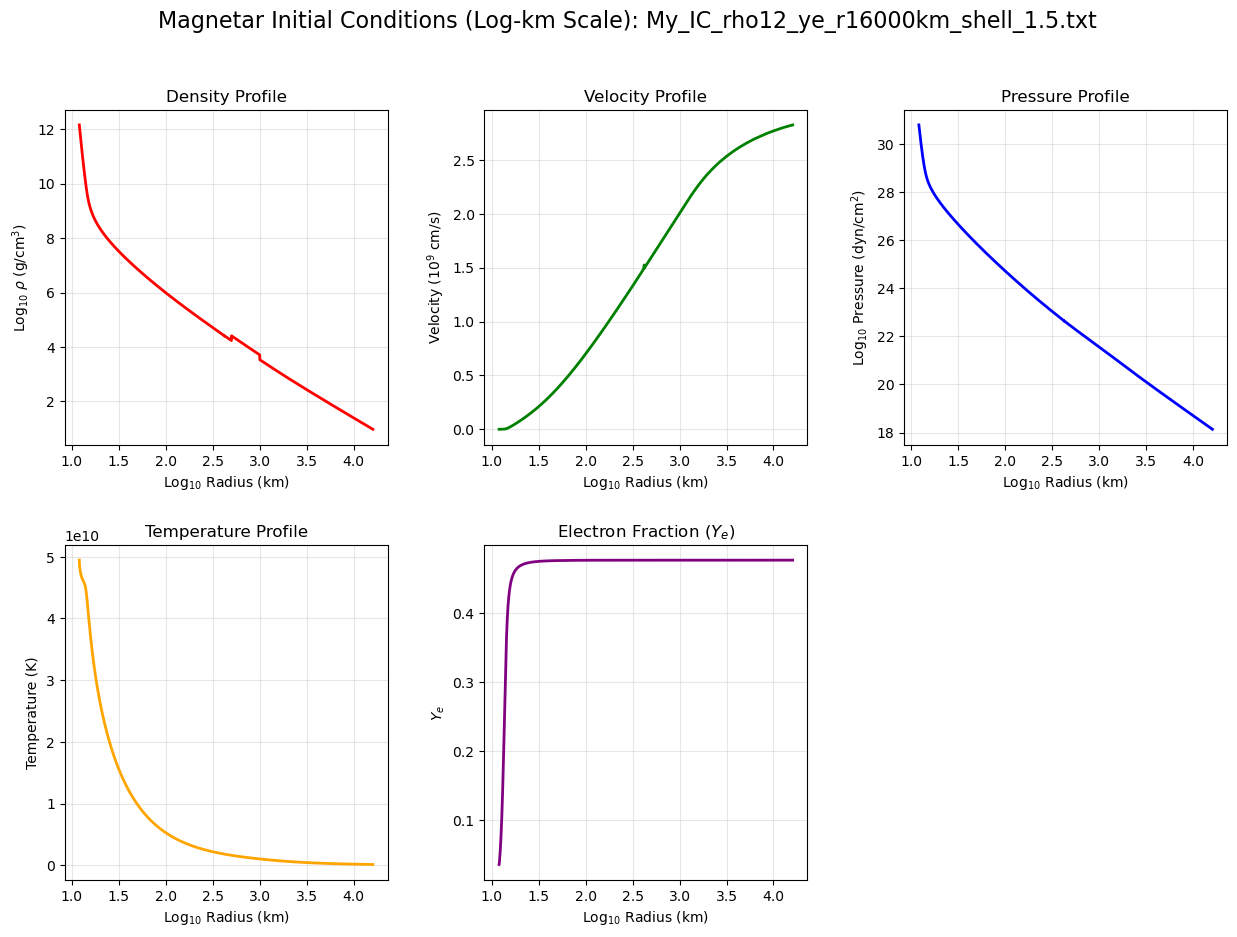

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load Data ---
file_path = '/Users/jackson.4406/Magnetar_OSC_OG/My_IC_rho12_ye_r16000km_shell_1.5.txt'

try:
    data = np.loadtxt(file_path)
    # Convert Radius from cm to km for the x-axis
    radius_km = data[:, 0] / 1e5  
    log_r = np.log10(radius_km)
    
    density = data[:, 1]
    velocity = data[:, 2] # Swapped per Todd's request & athinput
    temp = data[:, 3]     # Swapped per Todd's request & athinput
    pressure = data[:, 4]
    ye = data[:, 5]
except FileNotFoundError:
    print("File not found. Ensure the path to My_IC_shell_experiment is correct.")

# --- 2. Create Plotting Grid ---
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Density (Log scale)
axs[0, 0].plot(log_r, np.log10(density), color='red', lw=2)
axs[0, 0].set_title('Density Profile')
axs[0, 0].set_ylabel(r'Log$_{10}$ $\rho$ (g/cm$^3$)')

# Velocity (Fixed Panel)
axs[0, 1].plot(log_r, velocity / 1e9, color='green', lw=2)
axs[0, 1].set_title('Velocity Profile')
axs[0, 1].set_ylabel(r'Velocity ($10^9$ cm/s)')

# Pressure (Log scale)
axs[0, 2].plot(log_r, np.log10(pressure), color='blue', lw=2)
axs[0, 2].set_title('Pressure Profile')
axs[0, 2].set_ylabel(r'Log$_{10}$ Pressure (dyn/cm$^2$)')

# Temperature (Fixed Panel - Values are in Kelvin)
axs[1, 0].plot(log_r, temp, color='orange', lw=2)
axs[1, 0].set_title('Temperature Profile')
axs[1, 0].set_ylabel('Temperature (K)')

# Electron Fraction (Ye)
axs[1, 1].plot(log_r, ye, color='purple', lw=2)
axs[1, 1].set_title('Electron Fraction ($Y_e$)')
axs[1, 1].set_ylabel('$Y_e$')

# Blank panel for future shell comparison
axs[1, 2].axis('off')

# Common X-axis label for all relevant plots
for ax in axs.flat:
    if ax != axs[1, 2]:
        ax.set_xlabel(r'Log$_{10}$ Radius (km)')
        ax.grid(True, alpha=0.3)

plt.suptitle(f'Magnetar Initial Conditions (Log-km Scale): {file_path.split("/")[-1]}', fontsize=16)
plt.savefig('magnetar_initial_conditions_shell_1.5.jpg', dpi=300)
plt.show()

## Changing Density and Velocity for Shell 

In [14]:
import numpy as np
import os

# --- 1. Configuration ---
input_file = '/Users/jackson.4406/Magnetar_OSC_OG/My_IC_rho12_ye_r16000km.txt'
base_output_path = '/Users/jackson.4406/Magnetar_OSC_OG/My_IC_rho12_ye_r16000km_shell'

# Define the multipliers: start at 1.1, end at 2.0, in increments of 0.1
# np.linspace(1.1, 2.0, 10) creates exactly 10 steps: 1.1, 1.2, ..., 2.0
multipliers = np.arange(1.5, 5.5, 0.5)

try:
    # Load the original data once to save time
    original_data = np.loadtxt(input_file)
    print(f"Loaded original ICs from: {input_file}")
    
    # --- 2. Automation Loop ---
    for factor in multipliers:
        # Create a fresh copy of the data for each iteration
        data = original_data.copy()
        
        # Define the shell mask (500km to 1000km)
        # Column 0: Radius (cm) | 5.0e7 cm = 500km, 1.0e8 cm = 1000km
        mask = (data[:, 0] >= 5.0e7) & (data[:, 0] <= 1.0e8)
        
        # Apply the current density scaling factor to Column 1 (rho)
        data[mask, 1] *= factor
        
        # Generate the dynamic output filename
        # :.1f ensures the factor appears as '1.1', '1.2', etc.
        output_file = f"{base_output_path}_{factor:.1f}.txt"
        
        # Save the new file
        np.savetxt(output_file, data, fmt='%.8e')
        
        num_modified = np.sum(mask)
        print(f"Successfully created: {os.path.basename(output_file)} (Factor: {factor:.1f}, Points modified: {num_modified})")

    print("\n--- All files generated successfully! ---")

except FileNotFoundError:
    print(f"Error: Could not find the input file at {input_file}")
except Exception as e:
    print(f"An error occurred: {e}")

Loaded original ICs from: /Users/jackson.4406/Magnetar_OSC_OG/My_IC_rho12_ye_r16000km.txt
Successfully created: My_IC_rho12_ye_r16000km_shell_1.5.txt (Factor: 1.5, Points modified: 667)
Successfully created: My_IC_rho12_ye_r16000km_shell_2.0.txt (Factor: 2.0, Points modified: 667)
Successfully created: My_IC_rho12_ye_r16000km_shell_2.5.txt (Factor: 2.5, Points modified: 667)
Successfully created: My_IC_rho12_ye_r16000km_shell_3.0.txt (Factor: 3.0, Points modified: 667)
Successfully created: My_IC_rho12_ye_r16000km_shell_3.5.txt (Factor: 3.5, Points modified: 667)
Successfully created: My_IC_rho12_ye_r16000km_shell_4.0.txt (Factor: 4.0, Points modified: 667)
Successfully created: My_IC_rho12_ye_r16000km_shell_4.5.txt (Factor: 4.5, Points modified: 667)
Successfully created: My_IC_rho12_ye_r16000km_shell_5.0.txt (Factor: 5.0, Points modified: 667)

--- All files generated successfully! ---


In [8]:
import numpy as np
import os

# --- 1. Configuration ---
input_file = '/Users/jackson.4406/Magnetar_OSC_OG/My_IC_rho12_ye_r16000km.txt'
base_output_path = '/Users/jackson.4406/Magnetar_OSC_OG/My_IC_rho12_ye_r16000km_shell'

# Generates factors: 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0
multipliers = np.arange(1.5, 5.1, 0.5)

try:
    # Load the original data once to save time
    original_data = np.loadtxt(input_file)
    print(f"Loaded original ICs from: {input_file}")
    
    # --- 2. Automation Loop ---
    for factor in multipliers:
        # Create a fresh copy of the data for each iteration
        data = original_data.copy()
        
        # Define the shell mask (500km to 1000km)
        # Column 0: Radius (cm) | 5.0e7 cm = 500km, 1.0e8 cm = 1000km
        mask = (data[:, 0] >= 5.0e7) & (data[:, 0] <= 1.0e8)
        
        # 1. Apply the current density scaling factor to Column 1 (rho)
        data[mask, 1] *= factor
        
        # 2. Scale the temperature/internal energy column by 0.5 (Column 3)
        data[mask, 3] *= 0.5
        
        # Generate the dynamic output filename with both factors included
        output_file = f"{base_output_path}_{factor:.1f}_t0.5.txt"
        
        # Save the new file
        np.savetxt(output_file, data, fmt='%.8e')
        
        num_modified = np.sum(mask)
        print(f"Successfully created: {os.path.basename(output_file)} (Density Factor: {factor:.1f}, Temp Factor: 0.5, Points modified: {num_modified})")

    print("\n--- All files generated successfully! ---")

except FileNotFoundError:
    print(f"Error: Could not find the input file at {input_file}")
except Exception as e:
    print(f"An error occurred: {e}")

Loaded original ICs from: /Users/jackson.4406/Magnetar_OSC_OG/My_IC_rho12_ye_r16000km.txt
Successfully created: My_IC_rho12_ye_r16000km_shell_1.5_t0.5.txt (Density Factor: 1.5, Temp Factor: 0.5, Points modified: 667)
Successfully created: My_IC_rho12_ye_r16000km_shell_2.0_t0.5.txt (Density Factor: 2.0, Temp Factor: 0.5, Points modified: 667)
Successfully created: My_IC_rho12_ye_r16000km_shell_2.5_t0.5.txt (Density Factor: 2.5, Temp Factor: 0.5, Points modified: 667)
Successfully created: My_IC_rho12_ye_r16000km_shell_3.0_t0.5.txt (Density Factor: 3.0, Temp Factor: 0.5, Points modified: 667)
Successfully created: My_IC_rho12_ye_r16000km_shell_3.5_t0.5.txt (Density Factor: 3.5, Temp Factor: 0.5, Points modified: 667)
Successfully created: My_IC_rho12_ye_r16000km_shell_4.0_t0.5.txt (Density Factor: 4.0, Temp Factor: 0.5, Points modified: 667)
Successfully created: My_IC_rho12_ye_r16000km_shell_4.5_t0.5.txt (Density Factor: 4.5, Temp Factor: 0.5, Points modified: 667)
Successfully created:

In [14]:
import numpy as np
import os

# --- 1. Configuration ---
input_file = '/Users/jackson.4406/Magnetar_OSC_OG/My_IC_rho12_ye_r16000km.txt'
output_file = '/Users/jackson.4406/Magnetar_OSC_OG/My_IC_rho12_ye_r16000km_density_10.txt'

try:
    # Load the original data
    data = np.loadtxt(input_file)
    print(f"Loaded original ICs from: {input_file}")
    
    # --- 2. Apply Modifications ---
    # Define the mask for everything outside of 500km (5.0e7 cm)
    mask = (data[:, 0] >= 5.0e7)
    
    # Multiply density (Column 1) by a factor of 10 outside 500 km
    data[mask, 1] *= 10.0
    
    # Column 3 (Temperature) is left completely unmodified as requested
    
    # --- 3. Save Output ---
    np.savetxt(output_file, data, fmt='%.8e')
    
    num_modified = np.sum(mask)
    print(f"\nSuccessfully created: {os.path.basename(output_file)}")
    print(f"Points modified outside 500km: {num_modified}")
    print("Temperature profile remained unaltered.")

except FileNotFoundError:
    print(f"Error: Could not find the input file at {input_file}")
except Exception as e:
    print(f"An error occurred: {e}")

Loaded original ICs from: /Users/jackson.4406/Magnetar_OSC_OG/My_IC_rho12_ye_r16000km.txt

Successfully created: My_IC_rho12_ye_r16000km_density_10.txt
Points modified outside 500km: 20678
Temperature profile remained unaltered.
